In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/Delhi_House_Data.csv")
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.shape

Rows: 1259
Columns: 11


(1259, 11)

In [4]:
df.columns.tolist()

['Area',
 'BHK',
 'Bathroom',
 'Furnishing',
 'Locality',
 'Parking',
 'Price',
 'Status',
 'Transaction',
 'Type',
 'Per_Sqft']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   str    
 4   Locality     1259 non-null   str    
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   str    
 8   Transaction  1259 non-null   str    
 9   Type         1254 non-null   str    
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 108.3 KB


In [6]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Per_Sqft      241
Parking        33
Furnishing      5
Type            5
Bathroom        2
dtype: int64

In [7]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

Per_Sqft      19.142176
Parking        2.621128
Type           0.397141
Furnishing     0.397141
Bathroom       0.158856
dtype: float64

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 83


In [9]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [10]:
df.describe(include="object")

C:\Users\Asus\AppData\Local\Temp\ipykernel_20344\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Furnishing,Locality,Status,Transaction,Type
count,1254,1259,1259,1259,1254
unique,3,365,2,2,2
top,Semi-Furnished,Lajpat Nagar 3,Ready_to_move,Resale,Builder_Floor
freq,708,34,1184,781,661


In [11]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n===== {column} =====")
    print("Unique:", df[column].nunique())
    print(df[column].unique()[:20])


===== Furnishing =====
Unique: 3
<StringArray>
['Semi-Furnished', 'Furnished', 'Unfurnished', nan]
Length: 4, dtype: str

===== Locality =====
Unique: 365
<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

C:\Users\Asus\AppData\Local\Temp\ipykernel_20344\543879931.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [12]:
numerical_columns = df.select_dtypes(include=np.number).columns
print(numerical_columns)

Index(['Area', 'BHK', 'Bathroom', 'Parking', 'Price', 'Per_Sqft'], dtype='str')


numerical_columns = df.select_dtypes(include=np.number).columns
print(numerical_columns)

In [13]:
for column in numerical_columns:
    print(f"\n===== {column} =====")
    print("Min:", df[column].min())
    print("Max:", df[column].max())
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())


===== Area =====
Min: 28.0
Max: 24300.0
Mean: 1466.4527241461478
Median: 1200.0

===== BHK =====
Min: 1
Max: 10
Mean: 2.796664019062748
Median: 3.0

===== Bathroom =====
Min: 1.0
Max: 7.0
Mean: 2.556085918854415
Median: 2.0

===== Parking =====
Min: 1.0
Max: 114.0
Mean: 1.935562805872757
Median: 1.0

===== Price =====
Min: 1000000
Max: 240000000
Mean: 21306703.733121525
Median: 14200000.0

===== Per_Sqft =====
Min: 1259.0
Max: 183333.0
Mean: 15690.136542239685
Median: 11291.5


In [14]:
df["Price"].head()
df["Price"].describe()

count    1.259000e+03
mean     2.130670e+07
std      2.560115e+07
min      1.000000e+06
25%      5.700000e+06
50%      1.420000e+07
75%      2.550000e+07
max      2.400000e+08
Name: Price, dtype: float64

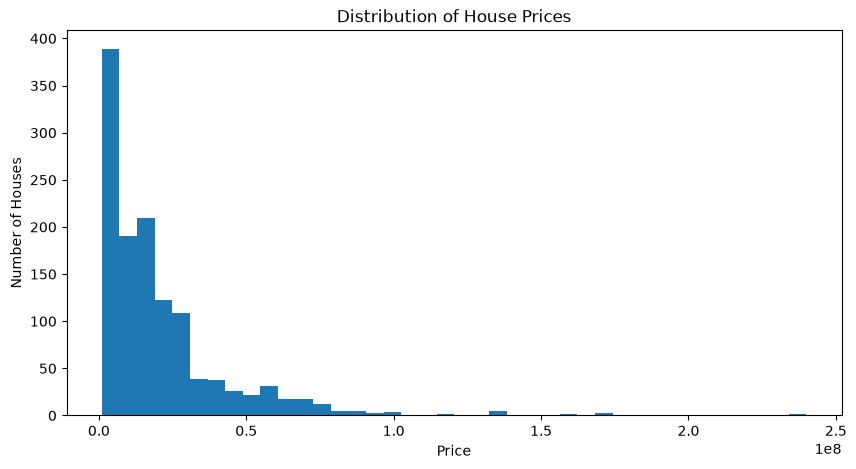

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["Price"].dropna(), bins=40)

plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")

plt.show()

In [16]:
df.columns = df.columns.str.strip()

In [17]:
df = df.dropna(how="all")

In [18]:
df = df.drop_duplicates()

In [19]:
print("Shape after basic cleaning:", df.shape)

Shape after basic cleaning: (1176, 11)


In [20]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/Delhi_House_Data_cleaned.csv",
    index=False
)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/Delhi_House_Data_cleaned.csv")

df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [22]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (1176, 11)

Columns:
['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price', 'Status', 'Transaction', 'Type', 'Per_Sqft']


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1176 non-null   float64
 1   BHK          1176 non-null   int64  
 2   Bathroom     1175 non-null   float64
 3   Furnishing   1171 non-null   str    
 4   Locality     1176 non-null   str    
 5   Parking      1145 non-null   float64
 6   Price        1176 non-null   int64  
 7   Status       1176 non-null   str    
 8   Transaction  1176 non-null   str    
 9   Type         1171 non-null   str    
 10  Per_Sqft     949 non-null    float64
dtypes: float64(4), int64(2), str(5)
memory usage: 101.2 KB


In [24]:
df["Price"].describe()

count    1.176000e+03
mean     2.109173e+07
std      2.523174e+07
min      1.000000e+06
25%      5.800000e+06
50%      1.400000e+07
75%      2.600000e+07
max      2.400000e+08
Name: Price, dtype: float64

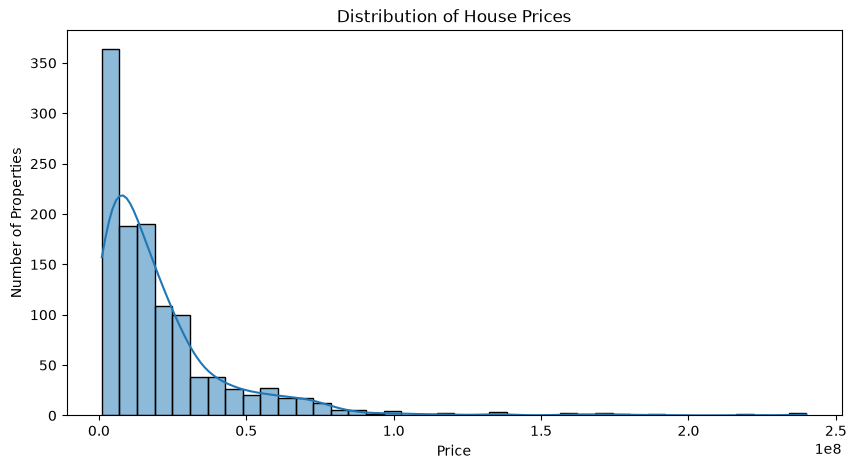

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Price"].dropna(), bins=40, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Properties")

plt.show()

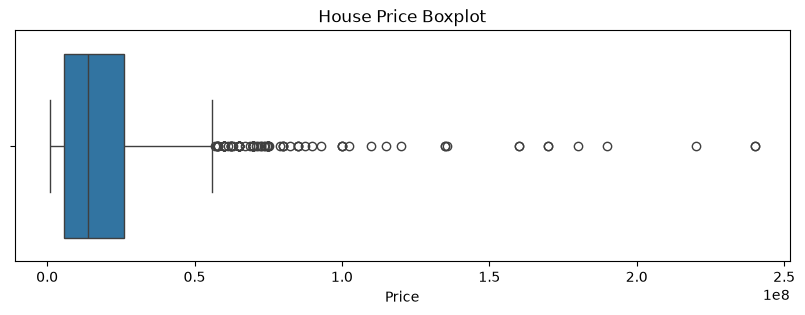

In [26]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=df["Price"])

plt.title("House Price Boxplot")
plt.xlabel("Price")

plt.show()

In [29]:
print(df["Area"].dtype)

float64


In [30]:
df["Area"].describe()

count     1176.000000
mean      1447.542711
std       1487.658687
min         28.000000
25%        800.000000
50%       1172.500000
75%       1700.000000
max      24300.000000
Name: Area, dtype: float64

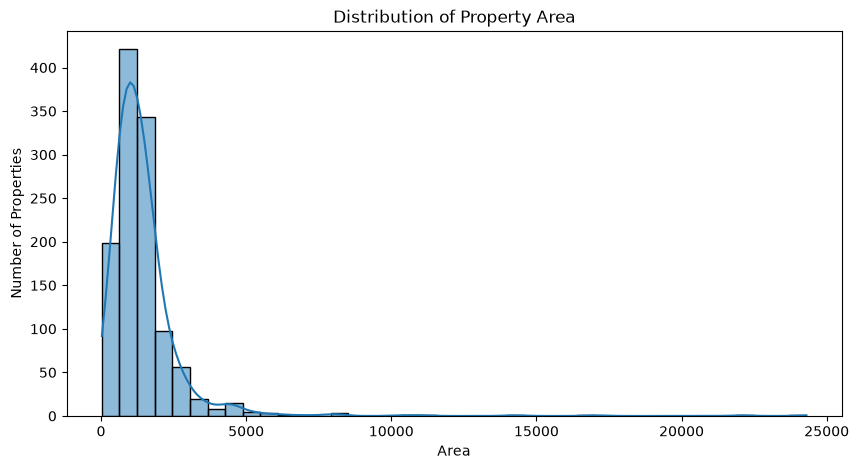

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Area"].dropna(), bins=40, kde=True)

plt.title("Distribution of Property Area")
plt.xlabel("Area")
plt.ylabel("Number of Properties")

plt.show()

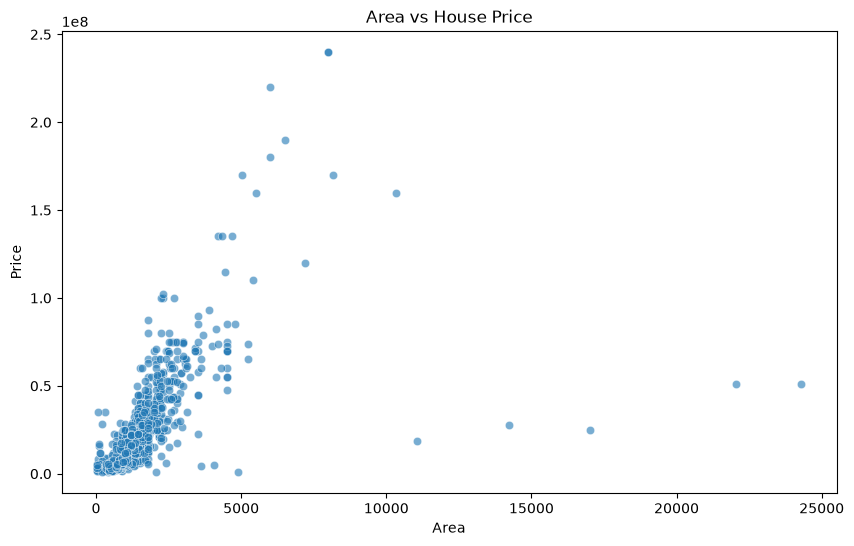

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Area",
    y="Price",
    alpha=0.6
)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

In [33]:
df.groupby("BHK")["Price"].agg(
    ["count", "mean", "median"]
).sort_index()

,count,mean,median
BHK,,,
1,94,2.970638e+06,2250000.0
2,342,8.662982e+06,7000000.0
3,501,1.917824e+07,17000000.0
4,208,4.729803e+07,43100000.0
5,23,8.003478e+07,65000000.0
6,6,3.855000e+07,15350000.0
7,1,2.650000e+07,26500000.0
10,1,1.700000e+07,17000000.0


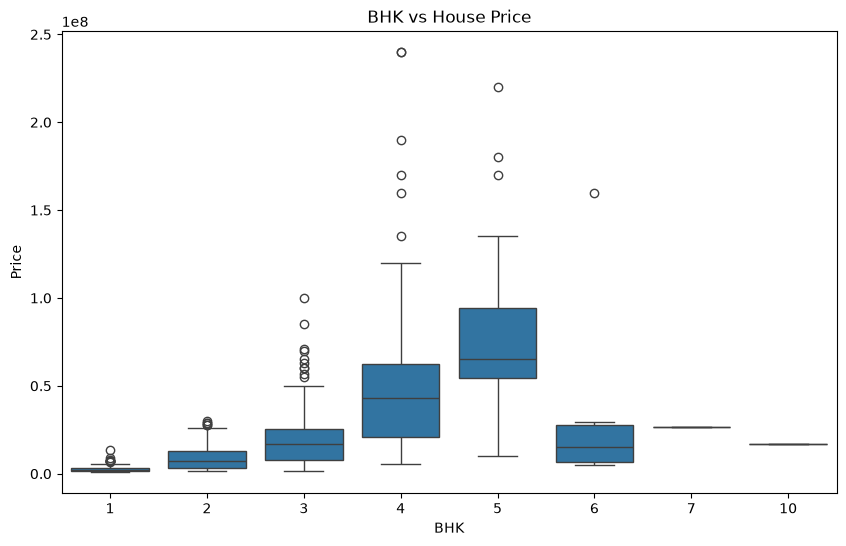

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="BHK",
    y="Price"
)

plt.title("BHK vs House Price")
plt.xlabel("BHK")
plt.ylabel("Price")

plt.show()

In [35]:
df.groupby("Bathroom")["Price"].agg(
    ["count", "mean", "median"]
).sort_index()

,count,mean,median
Bathroom,,,
1.0,143,3.510070e+06,2500000.0
2.0,511,1.022552e+07,8300000.0
3.0,327,2.315566e+07,22500000.0
4.0,129,4.895419e+07,47000000.0
5.0,56,7.621607e+07,63750000.0
6.0,6,8.573333e+07,61250000.0
7.0,3,1.312333e+08,160000000.0


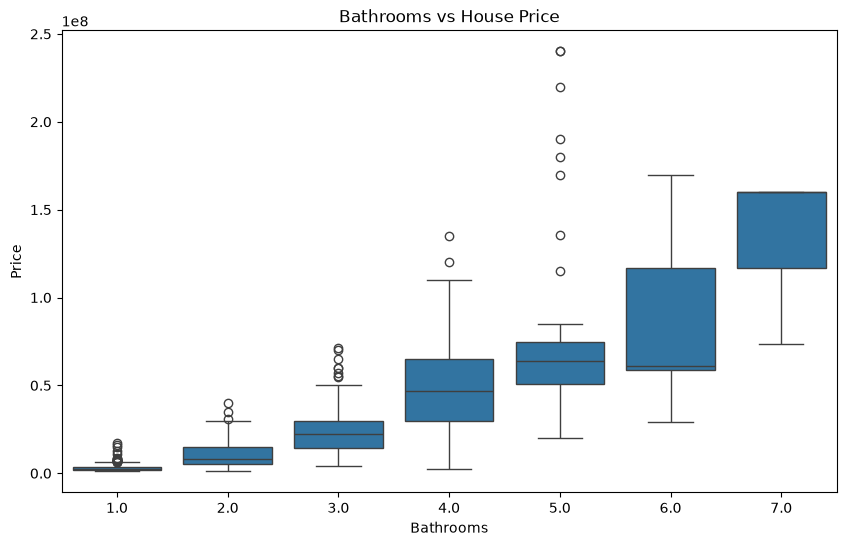

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Bathroom",
    y="Price"
)

plt.title("Bathrooms vs House Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")

plt.show()

In [37]:
print(df["Per_Sqft"].dtype)

float64


In [38]:
df["Per_Sqft"].describe()

count       949.000000
mean      15817.306639
std       21761.574205
min        1259.000000
25%        6471.000000
50%       11111.000000
75%       18000.000000
max      183333.000000
Name: Per_Sqft, dtype: float64

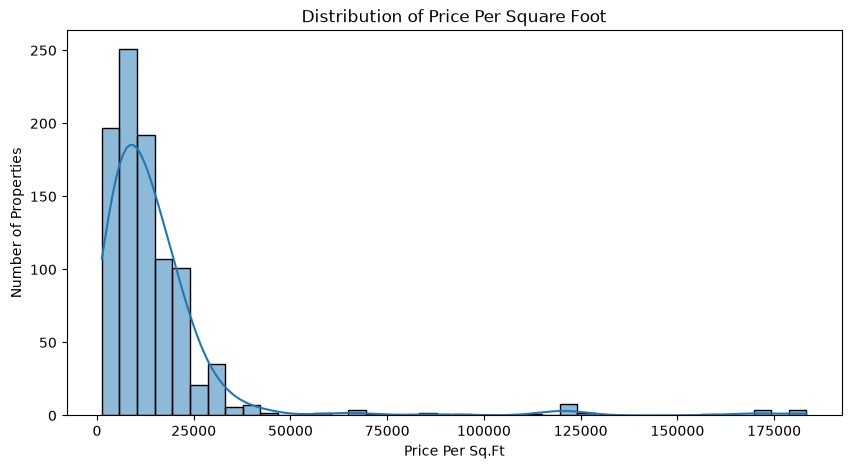

In [39]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Per_Sqft"].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Price Per Square Foot")
plt.xlabel("Price Per Sq.Ft")
plt.ylabel("Number of Properties")

plt.show()

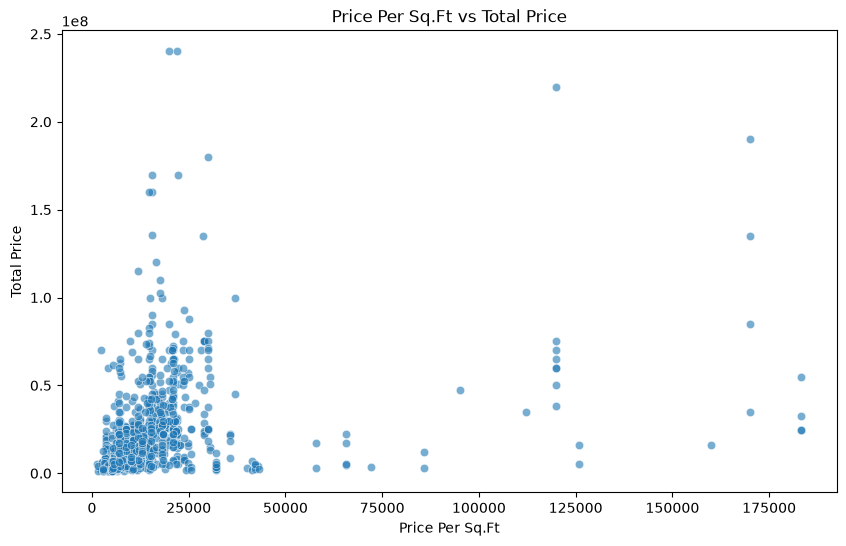

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Per_Sqft",
    y="Price",
    alpha=0.6
)

plt.title("Price Per Sq.Ft vs Total Price")
plt.xlabel("Price Per Sq.Ft")
plt.ylabel("Total Price")

plt.show()

In [41]:
df.groupby("Furnishing")["Price"].agg(
    ["count", "mean", "median"]
).sort_values("median", ascending=False)

,count,mean,median
Furnishing,,,
Semi-Furnished,667,2.303565e+07,15000000.0
Furnished,174,1.735529e+07,13550000.0
Unfurnished,330,1.924506e+07,11000000.0


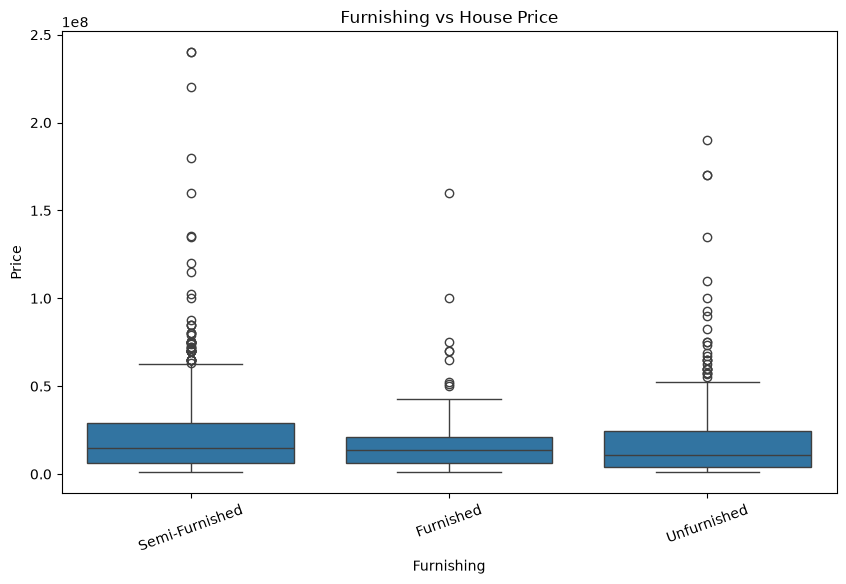

In [42]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="Price"
)

plt.title("Furnishing vs House Price")
plt.xlabel("Furnishing")
plt.ylabel("Price")

plt.xticks(rotation=20)

plt.show()

In [43]:
df["Parking"].value_counts(dropna=False)

Parking
1.0      737
2.0      321
3.0       54
NaN       31
4.0       14
5.0        7
39.0       7
114.0      3
9.0        1
10.0       1
Name: count, dtype: int64

In [44]:
df.groupby("Parking")["Price"].agg(
    ["count", "mean", "median"]
).sort_values("median", ascending=False)

,count,mean,median
Parking,,,
9.0,1,2.200000e+08,220000000.0
3.0,54,5.471759e+07,53750000.0
4.0,14,4.932143e+07,30500000.0
2.0,321,2.930480e+07,23000000.0
10.0,1,9.300000e+06,9300000.0
1.0,737,1.467936e+07,9000000.0
114.0,3,9.033333e+06,9000000.0
5.0,7,1.595714e+07,7200000.0
39.0,7,2.485714e+06,2000000.0


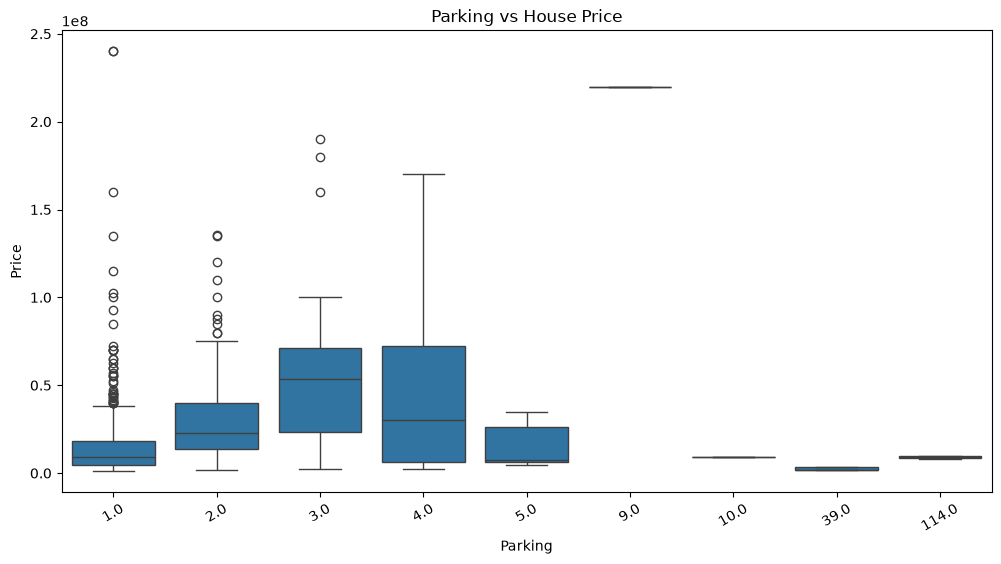

In [45]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Parking",
    y="Price"
)

plt.title("Parking vs House Price")
plt.xlabel("Parking")
plt.ylabel("Price")

plt.xticks(rotation=30)

plt.show()

In [46]:
df["Type"].value_counts(dropna=False)

Type
Builder_Floor    643
Apartment        528
NaN                5
Name: count, dtype: int64

In [47]:
df.groupby("Type")["Price"].agg(
    ["count", "mean", "median"]
).sort_values("median", ascending=False)

,count,mean,median
Type,,,
Apartment,528,1.781883e+07,14000000.0
Builder_Floor,643,2.383691e+07,13400000.0


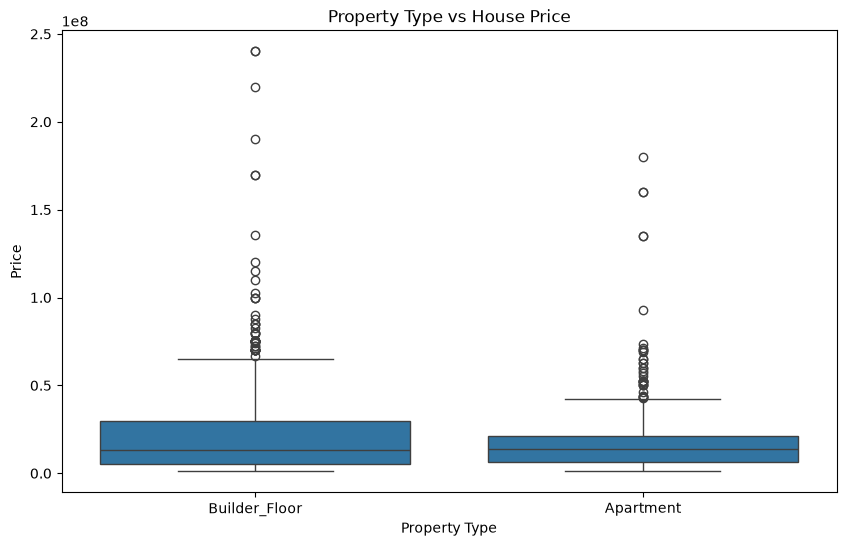

In [48]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Type",
    y="Price"
)

plt.title("Property Type vs House Price")
plt.xlabel("Property Type")
plt.ylabel("Price")

plt.show()

In [49]:
df["Transaction"].value_counts(dropna=False)

Transaction
Resale          741
New_Property    435
Name: count, dtype: int64

In [50]:
df.groupby("Transaction")["Price"].agg(
    ["count", "mean", "median"]
).sort_values("median", ascending=False)

,count,mean,median
Transaction,,,
New_Property,435,2.825343e+07,15000000.0
Resale,741,1.688749e+07,13500000.0


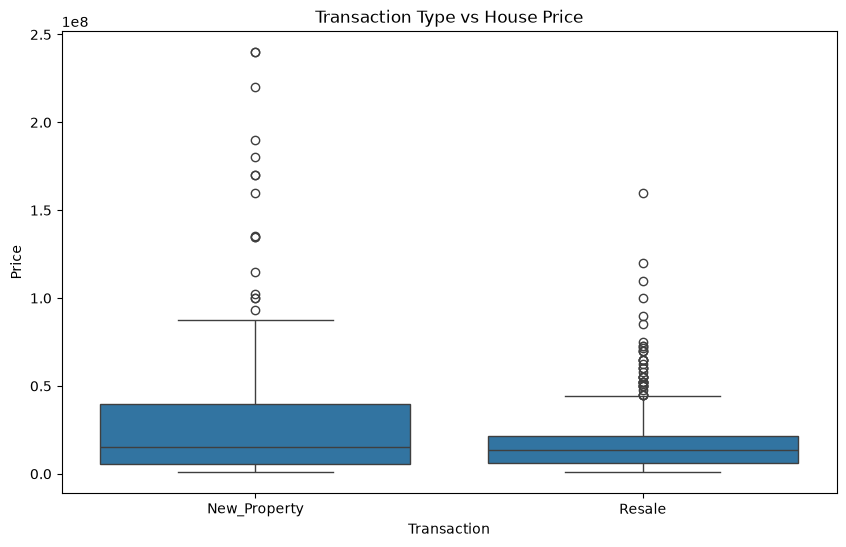

In [51]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Transaction",
    y="Price"
)

plt.title("Transaction Type vs House Price")
plt.xlabel("Transaction")
plt.ylabel("Price")

plt.show()

In [52]:
df["Status"].value_counts(dropna=False)

Status
Ready_to_move    1115
Almost_ready       61
Name: count, dtype: int64

In [53]:
df.groupby("Status")["Price"].agg(
    ["count", "mean", "median"]
).sort_values("median", ascending=False)

,count,mean,median
Status,,,
Almost_ready,61,3.427803e+07,24900000.0
Ready_to_move,1115,2.037032e+07,13500000.0


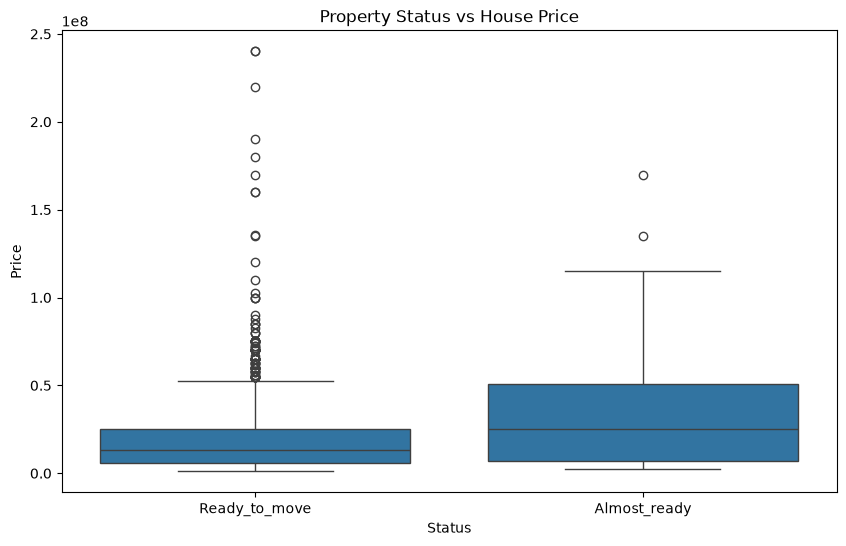

In [54]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Status",
    y="Price"
)

plt.title("Property Status vs House Price")
plt.xlabel("Status")
plt.ylabel("Price")

plt.show()

In [55]:
print("Number of Localities:", df["Locality"].nunique())

Number of Localities: 365


In [57]:
locality_counts = df["Locality"].value_counts()
locality_counts.head(20)

Locality
Lajpat Nagar 3                                                  32
Lajpat Nagar 2                                                  30
Kailash Colony, Greater Kailash                                 30
Yamuna Vihar, Shahdara                                          29
J R Designers Floors, Rohini Sector 24                          28
Mehrauli                                                        24
Chittaranjan Park                                               24
Laxmi Nagar                                                     23
Saket                                                           21
DDA Flats Sarita Vihar, Sarita Vihar, Mathura Road              19
Safdarjung Enclave                                              18
Chhattarpur                                                     17
Sheikh Sarai Phase 1                                            17
Dilshad Colony, Dilshad Garden                                  16
Patel Nagar West                                     

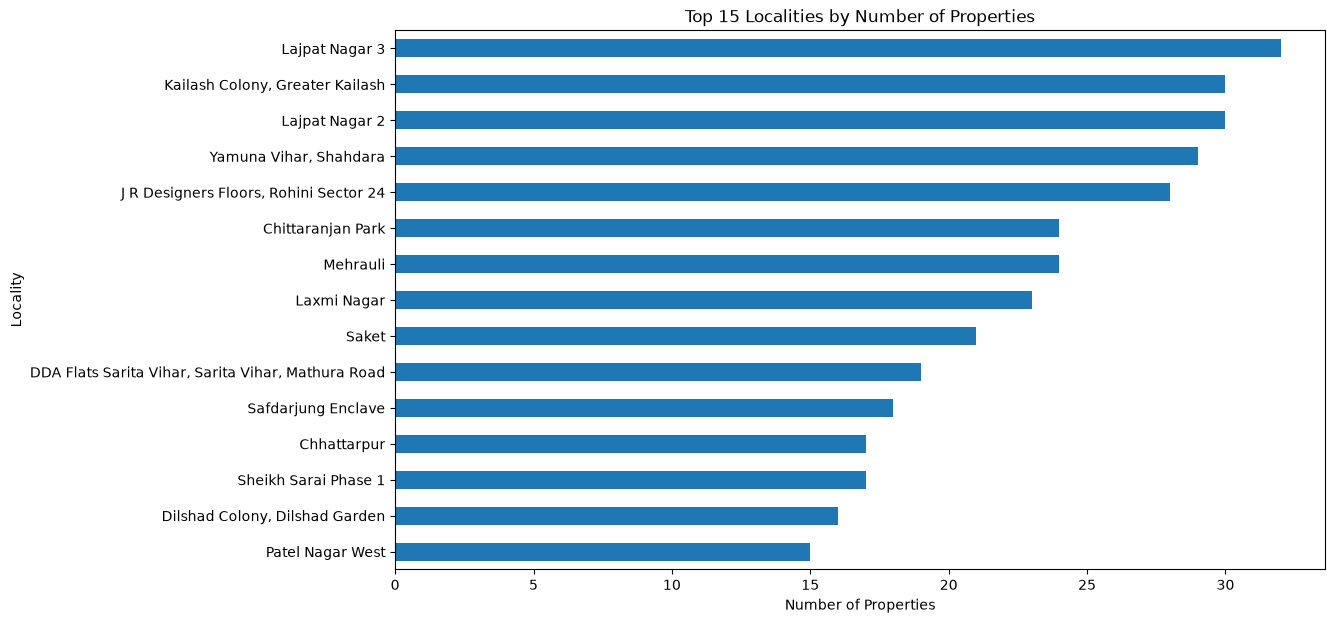

In [58]:
plt.figure(figsize=(12, 7))

locality_counts.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Localities by Number of Properties")
plt.xlabel("Number of Properties")
plt.ylabel("Locality")

plt.show()

In [59]:
top_localities = (
    df["Locality"]
    .value_counts()
    .head(15)
    .index
)

locality_price = (
    df[df["Locality"].isin(top_localities)]
    .groupby("Locality")["Price"]
    .median()
    .sort_values()
)

locality_price

Locality
Mehrauli                                               3350000.0
Chhattarpur                                            4400000.0
Dilshad Colony, Dilshad Garden                         5400000.0
J R Designers Floors, Rohini Sector 24                 5500000.0
Laxmi Nagar                                            5600000.0
Yamuna Vihar, Shahdara                                 8000000.0
Patel Nagar West                                      10400000.0
DDA Flats Sarita Vihar, Sarita Vihar, Mathura Road    13600000.0
Lajpat Nagar 2                                        15650000.0
Sheikh Sarai Phase 1                                  19000000.0
Chittaranjan Park                                     22500000.0
Lajpat Nagar 3                                        30000000.0
Saket                                                 30500000.0
Kailash Colony, Greater Kailash                       44000000.0
Safdarjung Enclave                                    53750000.0
Name: Price, dty

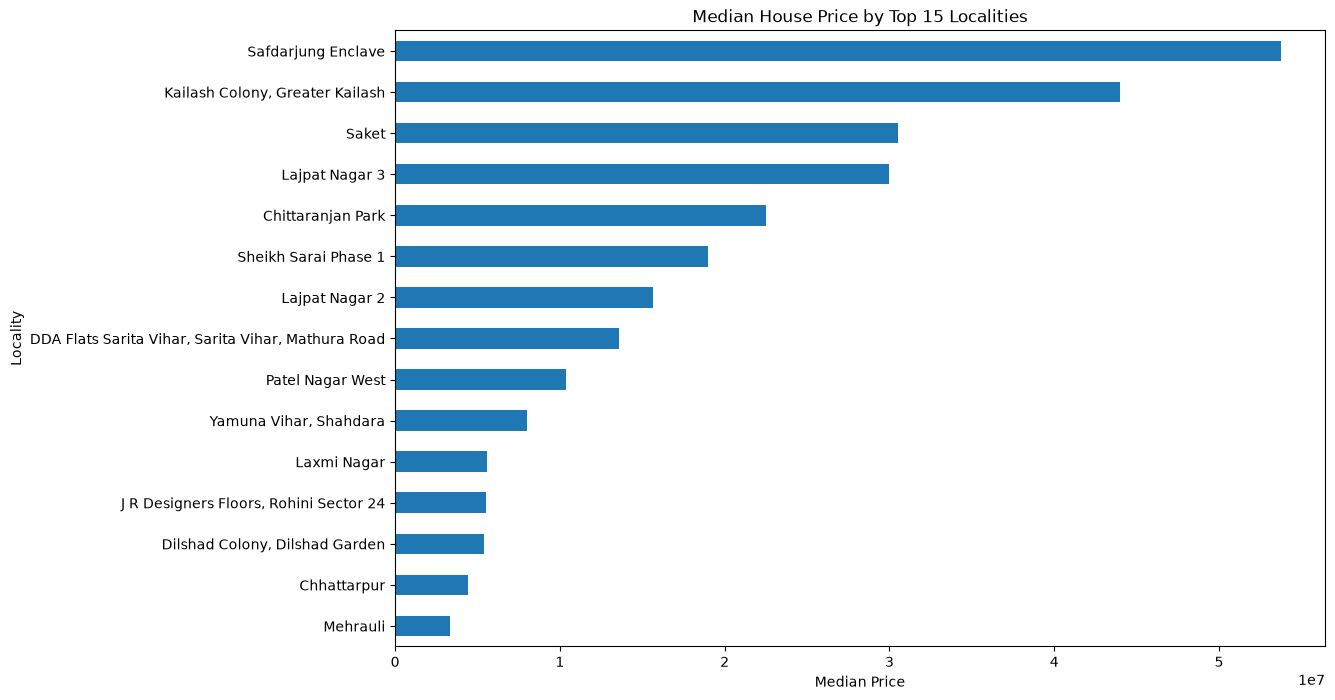

In [60]:
plt.figure(figsize=(12, 8))

locality_price.plot(kind="barh")

plt.title("Median House Price by Top 15 Localities")
plt.xlabel("Median Price")
plt.ylabel("Locality")

plt.show()

In [61]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
Area,1.000000,0.461125,0.554409,-0.010964,0.602679,0.161889
BHK,0.461125,1.000000,0.771053,-0.072551,0.566039,0.179493
Bathroom,0.554409,0.771053,1.000000,-0.035055,0.731663,0.217231
Parking,-0.010964,-0.072551,-0.035055,1.000000,-0.001833,-0.000116
Price,0.602679,0.566039,0.731663,-0.001833,1.000000,0.323747
Per_Sqft,0.161889,0.179493,0.217231,-0.000116,0.323747,1.000000


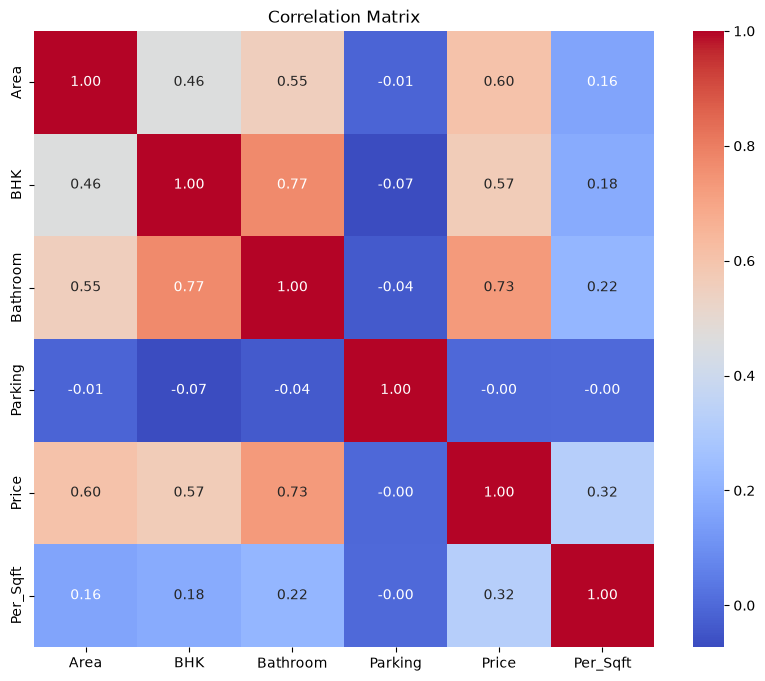

In [62]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [63]:
price_correlation = (
    correlation["Price"]
    .sort_values(ascending=False)
)

price_correlation

Price       1.000000
Bathroom    0.731663
Area        0.602679
BHK         0.566039
Per_Sqft    0.323747
Parking    -0.001833
Name: Price, dtype: float64

In [64]:
selected_columns = [
    "Price",
    "Area",
    "BHK",
    "Bathroom"
]

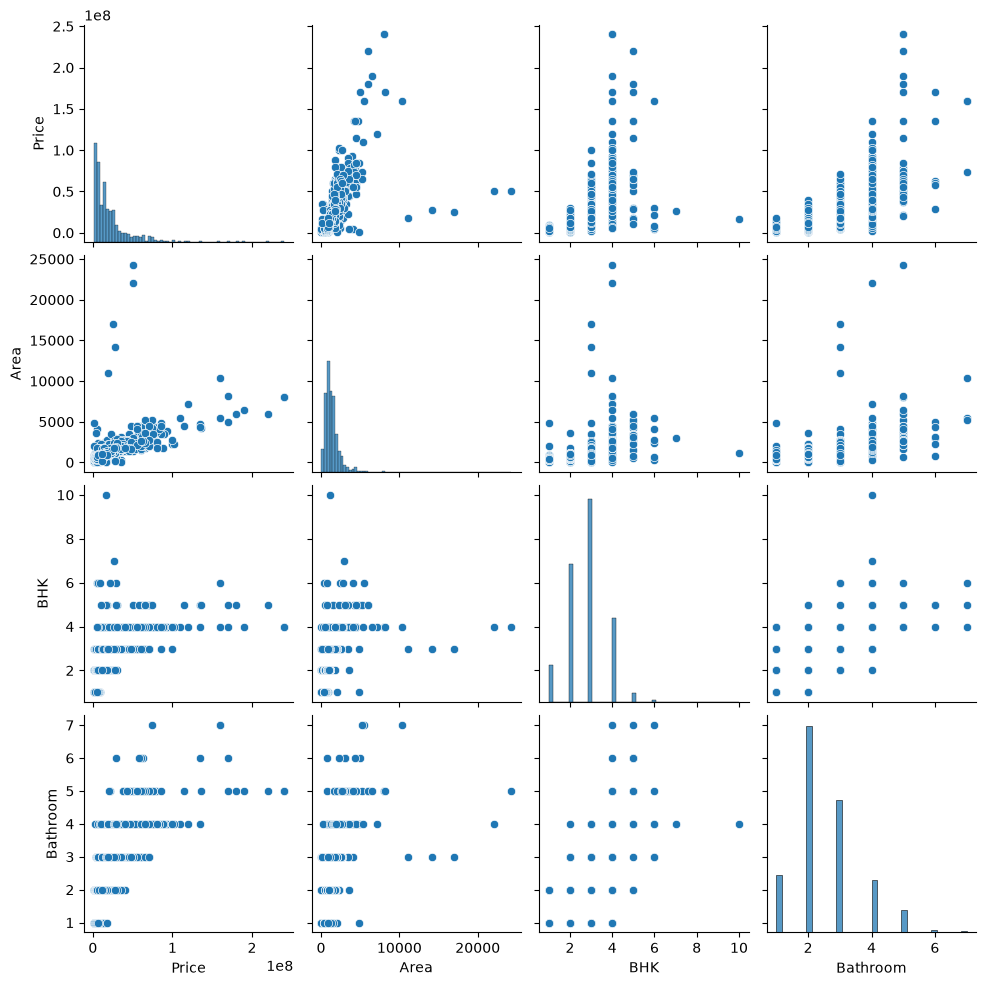

In [65]:
sns.pairplot(
    df[selected_columns].dropna()
)

plt.show()

In [67]:
df = pd.read_csv("../data/processed/Delhi_House_Data_cleaned.csv")
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [68]:
df = df.drop(columns=["Per_Sqft"])

In [69]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price',
       'Status', 'Transaction', 'Type'],
      dtype='str')

In [70]:
print(df["Area"].dtype)
print(df["Area"].head())

float64
0    800.0
1    750.0
2    950.0
3    600.0
4    650.0
Name: Area, dtype: float64


In [71]:
df["Area"] = pd.to_numeric(
    df["Area"],
    errors="coerce"
)

In [72]:
df["Area"].describe()

count     1176.000000
mean      1447.542711
std       1487.658687
min         28.000000
25%        800.000000
50%       1172.500000
75%       1700.000000
max      24300.000000
Name: Area, dtype: float64

In [73]:
df["Parking"].value_counts(dropna=False)

Parking
1.0      737
2.0      321
3.0       54
NaN       31
4.0       14
5.0        7
39.0       7
114.0      3
9.0        1
10.0       1
Name: count, dtype: int64

In [74]:
df["Parking"] = df["Parking"].fillna("Unknown")

In [75]:
categorical_columns = [
    "Furnishing",
    "Locality",
    "Parking",
    "Status",
    "Transaction",
    "Type"
]

In [76]:
for column in categorical_columns:
    print(f"\n===== {column} =====")
    print(df[column].value_counts(dropna=False).head(20))


===== Furnishing =====
Furnishing
Semi-Furnished    667
Unfurnished       330
Furnished         174
NaN                 5
Name: count, dtype: int64

===== Locality =====
Locality
Lajpat Nagar 3                                                  32
Lajpat Nagar 2                                                  30
Kailash Colony, Greater Kailash                                 30
Yamuna Vihar, Shahdara                                          29
J R Designers Floors, Rohini Sector 24                          28
Mehrauli                                                        24
Chittaranjan Park                                               24
Laxmi Nagar                                                     23
Saket                                                           21
DDA Flats Sarita Vihar, Sarita Vihar, Mathura Road              19
Safdarjung Enclave                                              18
Chhattarpur                                                     17
Sheikh Sarai Pha

In [77]:
for column in categorical_columns:
    df[column] = df[column].fillna("Unknown")

In [78]:
df[categorical_columns].isnull().sum()

Furnishing     0
Locality       0
Parking        0
Status         0
Transaction    0
Type           0
dtype: int64

In [79]:
df.isnull().sum()

Area           0
BHK            0
Bathroom       1
Furnishing     0
Locality       0
Parking        0
Price          0
Status         0
Transaction    0
Type           0
dtype: int64

In [84]:
df[df["Bathroom"].isnull()]

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Total_Rooms
30,1500.0,1,NaN,Unfurnished,Lajpat Nagar 2,Unknown,13500000,Ready_to_move,Resale,Apartment,NaN


In [85]:
df["Bathroom"] = df["Bathroom"].fillna(
    df["Bathroom"].median()
)

In [86]:
df.isnull().sum()

Area           0
BHK            0
Bathroom       0
Furnishing     0
Locality       0
Parking        0
Price          0
Status         0
Transaction    0
Type           0
Total_Rooms    1
dtype: int64

In [87]:
df["Total_Rooms"] = df["BHK"] + df["Bathroom"]
df.isnull().sum()

Area           0
BHK            0
Bathroom       0
Furnishing     0
Locality       0
Parking        0
Price          0
Status         0
Transaction    0
Type           0
Total_Rooms    0
dtype: int64

In [ ]:
df["Area_per_BHK"] = df["Area"] / df["BHK"]
df[["Area", "BHK", "Area_per_BHK"]].head()

,Area,BHK,Area_per_BHK
0,800.0,3,266.666667
1,750.0,2,375.000000
2,950.0,2,475.000000
3,600.0,2,300.000000
4,650.0,2,325.000000


In [89]:
df["Area_per_BHK"].isnull().sum()

np.int64(0)

In [90]:
print("BHK <= 0:", (df["BHK"] <= 0).sum())
print("Area <= 0:", (df["Area"] <= 0).sum())
print("Price <= 0:", (df["Price"] <= 0).sum())

BHK <= 0: 0
Area <= 0: 0
Price <= 0: 0


In [ ]:
numeric_features = df.select_dtypes(include=np.number)
numeric_features.corr()["Price"].sort_values(ascending=False)

Price           1.000000
Bathroom        0.731684
Total_Rooms     0.693532
Area            0.602679
BHK             0.566039
Area_per_BHK    0.415374
Name: Price, dtype: float64

In [92]:
features = [
    "Area",
    "BHK",
    "Bathroom",
    "Furnishing",
    "Locality",
    "Parking",
    "Status",
    "Transaction",
    "Type",
    "Total_Rooms",
    "Area_per_BHK"
]

target = "Price"

In [93]:
X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1176, 11)
y shape: (1176,)


In [94]:
print("Features:")
for feature in features:
    print("-", feature)

print("\nTarget:")
print("-", target)

Features:
- Area
- BHK
- Bathroom
- Furnishing
- Locality
- Parking
- Status
- Transaction
- Type
- Total_Rooms
- Area_per_BHK

Target:
- Price


In [95]:
print("Missing values:")
print(df[features + [target]].isnull().sum())

Missing values:
Area            0
BHK             0
Bathroom        0
Furnishing      0
Locality        0
Parking         0
Status          0
Transaction     0
Type            0
Total_Rooms     0
Area_per_BHK    0
Price           0
dtype: int64


In [96]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/Delhi_House_Data_feature_engineered.csv",
    index=False
)

print("Feature-engineered dataset saved successfully!")

Feature-engineered dataset saved successfully!


In [97]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (1176, 12)

Columns:
['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price', 'Status', 'Transaction', 'Type', 'Total_Rooms', 'Area_per_BHK']


,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Total_Rooms,Area_per_BHK
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,5.0,266.666667
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,4.0,375.000000
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,4.0,475.000000
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,4.0,300.000000
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,4.0,325.000000


In [98]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [101]:
features = [
    "Area",
    "BHK",
    "Bathroom",
    "Furnishing",
    "Locality",
    "Parking",
    "Status",
    "Transaction",
    "Type",
    "Total_Rooms",
    "Area_per_BHK"
]

target = "Price"

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1176, 11)
y shape: (1176,)


In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (940, 11)
Testing data: (236, 11)


In [104]:
numerical_features = [
    "Area",
    "BHK",
    "Bathroom",
    "Total_Rooms",
    "Area_per_BHK"
]

In [105]:
categorical_features = [
    "Furnishing",
    "Locality",
    "Parking",
    "Status",
    "Transaction",
    "Type"
]

In [106]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Area', 'BHK', 'Bathroom', 'Total_Rooms', 'Area_per_BHK']

Categorical features:
['Furnishing', 'Locality', 'Parking', 'Status', 'Transaction', 'Type']


In [107]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [108]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [109]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [113]:
# Convert categorical columns to strings
for column in categorical_features:
    X_train[column] = X_train[column].astype(str)
    X_test[column] = X_test[column].astype(str)

In [114]:
print(X_train[categorical_features].dtypes)

Furnishing     str
Locality       str
Parking        str
Status         str
Transaction    str
Type           str
dtype: object


In [115]:
X_train_processed = preprocessor.fit_transform(X_train)

In [116]:
X_test_processed = preprocessor.transform(X_test)

In [117]:
print("Original X_train:", X_train.shape)
print("Processed X_train:", X_train_processed.shape)

print("\nOriginal X_test:", X_test.shape)
print("Processed X_test:", X_test_processed.shape)

Original X_train: (940, 11)
Processed X_train: (940, 351)

Original X_test: (236, 11)
Processed X_test: (236, 351)


In [118]:
print(type(X_train_processed))

<class 'numpy.ndarray'>


In [119]:
feature_names = preprocessor.get_feature_names_out()

print("Total processed features:", len(feature_names))

Total processed features: 351


In [120]:
feature_names[:20]

array(['num__Area', 'num__BHK', 'num__Bathroom', 'num__Total_Rooms',
       'num__Area_per_BHK', 'cat__Furnishing_Furnished',
       'cat__Furnishing_Semi-Furnished', 'cat__Furnishing_Unfurnished',
       'cat__Furnishing_Unknown',
       'cat__Locality_APL Builder Floor, Greater Kailash 1',
       'cat__Locality_Aashirwaad Chowk, Dwarka',
       'cat__Locality_Abhimanyu Apartments, Vasundhara Enclave',
       'cat__Locality_Abul Fazal Enclave Part 1, Okhla',
       'cat__Locality_Abul Fazal Enclave Part-II, Okhla',
       'cat__Locality_Ahinsha Vatika, Ram Nagar, Shahdara',
       'cat__Locality_Alaknanda',
       'cat__Locality_Amar Colony, Lajpat Nagar',
       'cat__Locality_Andheria Mor, Mehrauli',
       'cat__Locality_Anekant Apartment, Vasundhara Enclave',
       'cat__Locality_Anupam Enclave, Saket'], dtype=object)

In [121]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

In [122]:
X_train_processed_df.head()

,num__Area,num__BHK,num__Bathroom,num__Total_Rooms,num__Area_per_BHK,cat__Furnishing_Furnished,cat__Furnishing_Semi-Furnished,cat__Furnishing_Unfurnished,cat__Furnishing_Unknown,"cat__Locality_APL Builder Floor, Greater Kailash 1","cat__Locality_Aashirwaad Chowk, Dwarka","cat__Locality_Abhimanyu Apartments, Vasundhara Enclave","cat__Locality_Abul Fazal Enclave Part 1, Okhla","cat__Locality_Abul Fazal Enclave Part-II, Okhla","cat__Locality_Ahinsha Vatika, Ram Nagar, Shahdara",cat__Locality_Alaknanda,"cat__Locality_Amar Colony, Lajpat Nagar","cat__Locality_Andheria Mor, Mehrauli","cat__Locality_Anekant Apartment, Vasundhara Enclave","cat__Locality_Anupam Enclave, Saket","cat__Locality_Apna Apartments, Savitri Nagar Village, Sheikh Sarai","cat__Locality_Aravali Apartments, Alaknanda","cat__Locality_Aravali Tower, Chhattarpur","cat__Locality_Archana Apartment, Paschim Vihar","cat__Locality_Arjun Nagar, Safdarjung Enclave","cat__Locality_Arya Chittaranjan Park, Chittaranjan Park","cat__Locality_Ashirwad Apartments, Dwarka","cat__Locality_Ashirwad Apartments, Dwarka Sector 12","cat__Locality_Ashoka Apartment, Paschim Vihar Block A2","cat__Locality_Ashoka Apartments, Dwarka Sector 12","cat__Locality_Ashoka Enclave Apartment, Dwarka Sector 11","cat__Locality_Balbir Nagar, Shahdara","cat__Locality_Baljit Nagar, Patel Nagar","cat__Locality_Bank Apartments, Aashirwaad Chowk, Dwarka","cat__Locality_Bank Apartments, Aashirwaad Chowk, Dwarka carpet area 1550 sqft status Ready to Move floor 7 out of 7 floors transaction Resale furnishing Semi-Furnished facing North - East overlooking Garden/Park, Main Road society Bank Apartments car parking 1 Covered, 1 Open bathroom 2 balcony 3 ownership Freehold A spacious 3 Bedroom flat is available for sale in Dwarka , New Delhi.it is cornor building plenty of sunlight and airy. It is located on the 2 Floor. It has a covered area of 1500 Sq-ft. The flat has vitrified tiles & Mosiac flooring. The flat has 24 Hours Available water supply and No/Rare Powercut.. The property is fantastically located and is much sought-after. The property is available at a very competitive Price. read more Contact Agent View Phone No. Share Feedback Sikka Realtors Has Maximum Property Options Is the Top Agent of the Locality Is Trusted by All Users CRISIL Rating No of employees 12 Sikka Realtors Certified Agent Locality Superstar Aashirwaad Chowk, Dwarka 2500+ Buyers Served","cat__Locality_Bank Enclave, Laxmi Nagar","cat__Locality_Batla House Project, Batla House, Okhla","cat__Locality_Batla House, Okhla","cat__Locality_Beadon Pura, Karol Bagh How Auctions work? The borrower has the physical possession of the Property. However the lender (Bank) can legally sell the Property. carpet area 148 sqyrd status Ready to Move floor 3 out of 3 floors transaction Resale furnishing Semi-Furnished bathroom 2 balcony 3 ownership Freehold Contact Now Enquire Now Auction By Bank","cat__Locality_Bhagwan Das Nagar, Punjabi Bagh","cat__Locality_Bhorgarh, Narela","cat__Locality_Brijwasi Colony, Mehrauli",cat__Locality_Budh Vihar,cat__Locality_Budh Vihar Phase 1,cat__Locality_Budh Vihar Phase 2,"cat__Locality_Budh Vihar super area 50 sqyrd status Ready to Move floor Ground out of 2 floors transaction Resale furnishing Unfurnished facing East car parking 1 Open bathroom 1 balcony 2 ownership Freehold For Sale 2 BHK 50 yrd, 2 side open Ground Floor, First and Second Floor in H Block, Gali No. 04, Near Laxmi Narain Mandir, BudhVihar read more Contact Agent View Phone No. Share Feedback Agent Sahyog Properties 1000+ Buyers Served","cat__Locality_Capital Apartment, Vasundhara Enclave","cat__Locality_Chander Lok Apartment, Dwarka Sector 19",cat__Locality_Chhattarpur,cat__Locality_Chhattarpur Enclave Phase2,"cat__Locality_Chhattarpur carpet area 400 sqyrd status Ready to Move transaction New Property furnishing Semi-Furnished car parking 1 Covered, 1 Open bathroom 2 balcony 1 Newly Constructed Property It's a Ground floor Builder Floor Apartment in a b

In [123]:
print(
    "Missing values in processed training data:",
    X_train_processed_df.isnull().sum().sum()
)

print(
    "Missing values in processed test data:",
    X_test_processed_df.isnull().sum().sum()
)

Missing values in processed training data: 0
Missing values in processed test data: 0


In [124]:
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nMissing y_train:", y_train.isnull().sum())
print("Missing y_test:", y_test.isnull().sum())

y_train shape: (940,)
y_test shape: (236,)

Missing y_train: 0
Missing y_test: 0


In [125]:
import joblib

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [126]:
print("========== PREPROCESSING SUMMARY ==========")

print("Original features:", len(features))
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nOriginal training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nMissing values in processed train:",
      X_train_processed_df.isnull().sum().sum())

print("Missing values in processed test:",
      X_test_processed_df.isnull().sum().sum())

print("\nPreprocessor saved: YES")

========== PREPROCESSING SUMMARY ==========
Original features: 11
Numerical features: 5
Categorical features: 6

Original training shape: (940, 11)
Processed training shape: (940, 351)

Original testing shape: (236, 11)
Processed testing shape: (236, 351)

Missing values in processed train: 0
Missing values in processed test: 0

Preprocessor saved: YES


In [127]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

In [128]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    # Training metrics
    train_mae = mean_absolute_error(
        y_train,
        train_predictions
    )
    
    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_predictions
        )
    )
    
    train_r2 = r2_score(
        y_train,
        train_predictions
    )
    
    # Testing metrics
    test_mae = mean_absolute_error(
        y_test,
        test_predictions
    )
    
    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_predictions
        )
    )
    
    test_r2 = r2_score(
        y_test,
        test_predictions
    )
    
    return {
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }

In [129]:
linear_model = LinearRegression()

linear_results = evaluate_model(
    linear_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

linear_results

{'Train MAE': 4676869.553446806,
 'Test MAE': 9081730.753353741,
 'Train RMSE': np.float64(9306332.475769289),
 'Test RMSE': np.float64(18381271.54321483),
 'Train R2': 0.8462813277106966,
 'Test R2': 0.6336079767370729}

In [130]:
ridge_model = Ridge(alpha=1.0)

ridge_results = evaluate_model(
    ridge_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

ridge_results

{'Train MAE': 5838724.961797329,
 'Test MAE': 9247760.14266726,
 'Train RMSE': np.float64(10144997.811480325),
 'Test RMSE': np.float64(18210932.924480464),
 'Train R2': 0.817327399191472,
 'Test R2': 0.6403671970708957}

In [131]:
lasso_model = Lasso(
    alpha=0.001,
    max_iter=10000
)

lasso_results = evaluate_model(
    lasso_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

lasso_results

d:\Projects\house-price-prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.298226e+16, tolerance: 5.296e+13
  model = cd_fast.enet_coordinate_descent(


{'Train MAE': 4676869.75942163,
 'Test MAE': 9115850.88848814,
 'Train RMSE': np.float64(9306332.475769304),
 'Test RMSE': np.float64(18368607.20040399),
 'Train R2': 0.8462813277106962,
 'Test R2': 0.6341126769369594}

In [132]:
elastic_model = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_results = evaluate_model(
    elastic_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

elastic_results

d:\Projects\house-price-prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.151601e+16, tolerance: 5.296e+13
  model = cd_fast.enet_coordinate_descent(


{'Train MAE': 5382138.543383172,
 'Test MAE': 9189079.9048666,
 'Train RMSE': np.float64(9663540.001842635),
 'Test RMSE': np.float64(18158321.51812944),
 'Train R2': 0.834254405314276,
 'Test R2': 0.6424421546276384}

In [133]:
knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_results = evaluate_model(
    knn_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

knn_results

{'Train MAE': 5035144.680851064,
 'Test MAE': 7238203.389830508,
 'Train RMSE': np.float64(9671986.148204712),
 'Test RMSE': np.float64(15530190.513636028),
 'Train R2': 0.8339645481132811,
 'Test R2': 0.7384537635249928}

In [134]:
svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1
)

svr_results = evaluate_model(
    svr_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

svr_results

{'Train MAE': 14439818.025017466,
 'Test MAE': 16161461.852202484,
 'Train RMSE': np.float64(24791452.886134982),
 'Test RMSE': np.float64(31739191.680094395),
 'Train R2': -0.09087114649058559,
 'Test R2': -0.09241242877296396}

In [135]:
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_results = evaluate_model(
    tree_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

tree_results

{'Train MAE': 2798846.449556398,
 'Test MAE': 7263555.929352582,
 'Train RMSE': np.float64(4476108.164264983),
 'Test RMSE': np.float64(16538424.686822234),
 'Train R2': 0.9644392721055505,
 'Test R2': 0.7033917762188033}

In [136]:
results = pd.DataFrame({
    "Linear Regression": linear_results,
    "Ridge": ridge_results,
    "Lasso": lasso_results,
    "Elastic Net": elastic_results,
    "KNN": knn_results,
    "SVR": svr_results,
    "Decision Tree": tree_results
}).T

results

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Linear Regression,4.676870e+06,9.081731e+06,9.306332e+06,1.838127e+07,0.846281,0.633608
Ridge,5.838725e+06,9.247760e+06,1.014500e+07,1.821093e+07,0.817327,0.640367
Lasso,4.676870e+06,9.115851e+06,9.306332e+06,1.836861e+07,0.846281,0.634113
Elastic Net,5.382139e+06,9.189080e+06,9.663540e+06,1.815832e+07,0.834254,0.642442
KNN,5.035145e+06,7.238203e+06,9.671986e+06,1.553019e+07,0.833965,0.738454
SVR,1.443982e+07,1.616146e+07,2.479145e+07,3.173919e+07,-0.090871,-0.092412
Decision Tree,2.798846e+06,7.263556e+06,4.476108e+06,1.653842e+07,0.964439,0.703392


In [137]:
results.sort_values(
    by="Test R2",
    ascending=False
)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
KNN,5.035145e+06,7.238203e+06,9.671986e+06,1.553019e+07,0.833965,0.738454
Decision Tree,2.798846e+06,7.263556e+06,4.476108e+06,1.653842e+07,0.964439,0.703392
Elastic Net,5.382139e+06,9.189080e+06,9.663540e+06,1.815832e+07,0.834254,0.642442
Ridge,5.838725e+06,9.247760e+06,1.014500e+07,1.821093e+07,0.817327,0.640367
Lasso,4.676870e+06,9.115851e+06,9.306332e+06,1.836861e+07,0.846281,0.634113
Linear Regression,4.676870e+06,9.081731e+06,9.306332e+06,1.838127e+07,0.846281,0.633608
SVR,1.443982e+07,1.616146e+07,2.479145e+07,3.173919e+07,-0.090871,-0.092412


In [138]:
results.sort_values(
    by="Test RMSE",
    ascending=True
)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
KNN,5.035145e+06,7.238203e+06,9.671986e+06,1.553019e+07,0.833965,0.738454
Decision Tree,2.798846e+06,7.263556e+06,4.476108e+06,1.653842e+07,0.964439,0.703392
Elastic Net,5.382139e+06,9.189080e+06,9.663540e+06,1.815832e+07,0.834254,0.642442
Ridge,5.838725e+06,9.247760e+06,1.014500e+07,1.821093e+07,0.817327,0.640367
Lasso,4.676870e+06,9.115851e+06,9.306332e+06,1.836861e+07,0.846281,0.634113
Linear Regression,4.676870e+06,9.081731e+06,9.306332e+06,1.838127e+07,0.846281,0.633608
SVR,1.443982e+07,1.616146e+07,2.479145e+07,3.173919e+07,-0.090871,-0.092412


In [139]:
results.sort_values(
    by="Test MAE",
    ascending=True
)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
KNN,5.035145e+06,7.238203e+06,9.671986e+06,1.553019e+07,0.833965,0.738454
Decision Tree,2.798846e+06,7.263556e+06,4.476108e+06,1.653842e+07,0.964439,0.703392
Linear Regression,4.676870e+06,9.081731e+06,9.306332e+06,1.838127e+07,0.846281,0.633608
Lasso,4.676870e+06,9.115851e+06,9.306332e+06,1.836861e+07,0.846281,0.634113
Elastic Net,5.382139e+06,9.189080e+06,9.663540e+06,1.815832e+07,0.834254,0.642442
Ridge,5.838725e+06,9.247760e+06,1.014500e+07,1.821093e+07,0.817327,0.640367
SVR,1.443982e+07,1.616146e+07,2.479145e+07,3.173919e+07,-0.090871,-0.092412


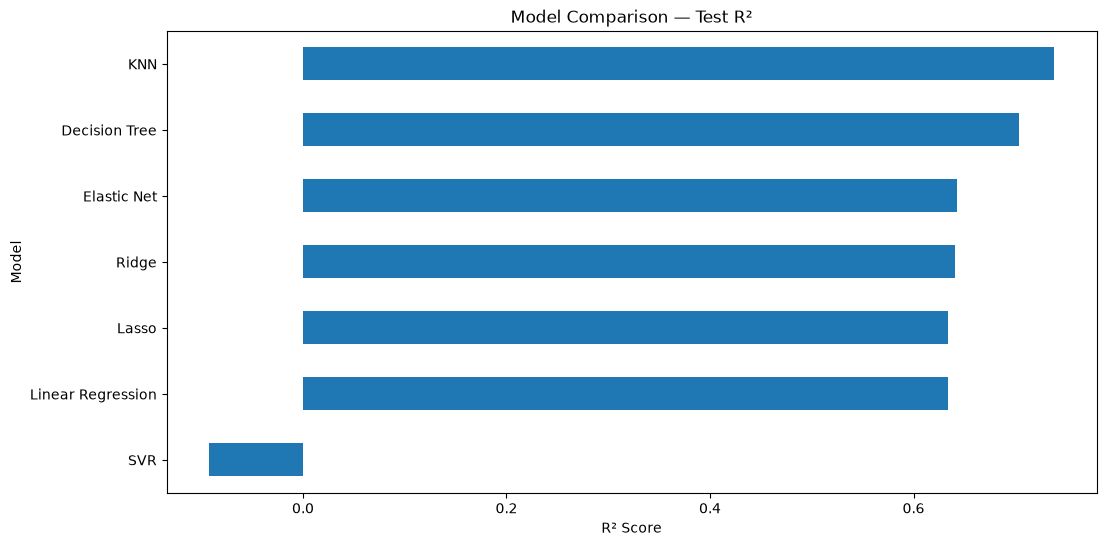

In [140]:
plt.figure(figsize=(12, 6))

results["Test R2"].sort_values().plot(
    kind="barh"
)

plt.title("Model Comparison — Test R²")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

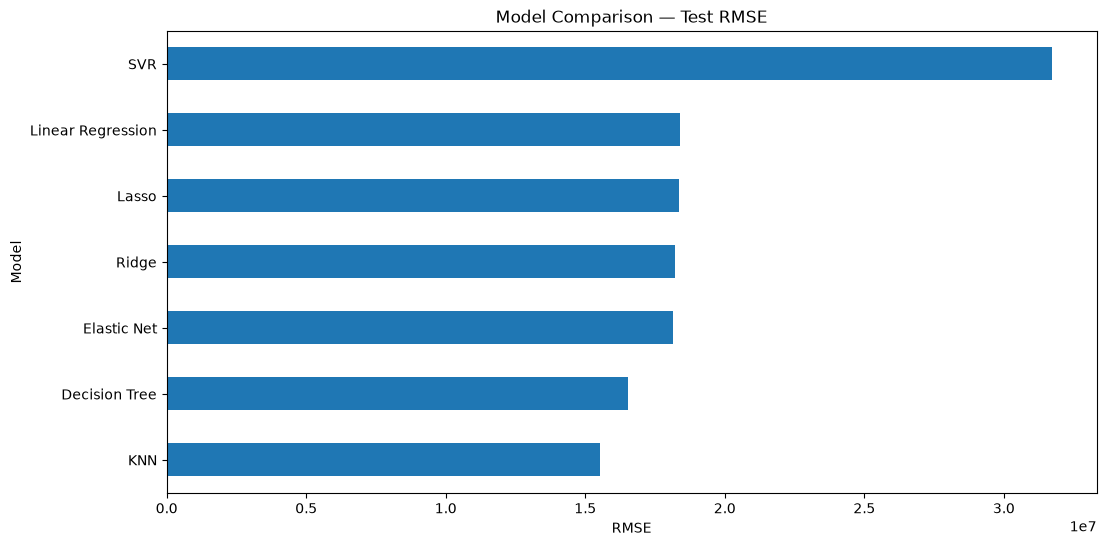

In [141]:
plt.figure(figsize=(12, 6))

results["Test RMSE"].sort_values().plot(
    kind="barh"
)

plt.title("Model Comparison — Test RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.show()

In [142]:
overfitting_check = results[
    [
        "Train R2",
        "Test R2"
    ]
].copy()

overfitting_check["R2 Gap"] = (
    overfitting_check["Train R2"]
    -
    overfitting_check["Test R2"]
)

overfitting_check.sort_values(
    by="R2 Gap",
    ascending=False
)

,Train R2,Test R2,R2 Gap
Decision Tree,0.964439,0.703392,0.261047
Linear Regression,0.846281,0.633608,0.212673
Lasso,0.846281,0.634113,0.212169
Elastic Net,0.834254,0.642442,0.191812
Ridge,0.817327,0.640367,0.176960
KNN,0.833965,0.738454,0.095511
SVR,-0.090871,-0.092412,0.001541


In [143]:
results.to_csv(
    "../data/processed/initial_model_results.csv"
)

print("Initial model results saved.")

Initial model results saved.


In [144]:
from sklearn.model_selection import KFold, cross_validate

In [145]:
models = {
    "Linear Regression": LinearRegression(),
    
    "Ridge": Ridge(alpha=1.0),
    
    "Lasso": Lasso(
        alpha=0.001,
        max_iter=10000
    ),
    
    "Elastic Net": ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=10000
    ),
    
    "KNN": KNeighborsRegressor(
        n_neighbors=5
    ),
    
    "SVR": SVR(
        kernel="rbf",
        C=100,
        epsilon=0.1
    ),
    
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    )
}

In [146]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [147]:
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

In [148]:
cv_results = []

for name, model in models.items():
    
    scores = cross_validate(
        model,
        X_train_processed,
        y_train,
        cv=kfold,
        scoring=scoring,
        return_train_score=True
    )
    
    cv_results.append({
        "Model": name,
        
        "CV Train R2": scores["train_r2"].mean(),
        "CV Validation R2": scores["test_r2"].mean(),
        
        "CV Train MAE": -scores["train_mae"].mean(),
        "CV Validation MAE": -scores["test_mae"].mean(),
        
        "CV Train RMSE": -scores["train_rmse"].mean(),
        "CV Validation RMSE": -scores["test_rmse"].mean()
    })

d:\Projects\house-price-prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.600041e+16, tolerance: 4.333e+13
  model = cd_fast.enet_coordinate_descent(
d:\Projects\house-price-prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.624115e+16, tolerance: 4.530e+13
  model = cd_fast.enet_coordinate_descent(
d:\Projects\house-price-prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

In [149]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,CV Train R2,CV Validation R2,CV Train MAE,CV Validation MAE,CV Train RMSE,CV Validation RMSE
0,Linear Regression,0.857712,0.627349,4.443424e+06,7.749589e+06,8.943644e+06,1.417300e+07
1,Ridge,0.825732,0.652170,5.738278e+06,7.750047e+06,9.900944e+06,1.373667e+07
2,Lasso,0.857712,0.627230,4.443424e+06,7.778767e+06,8.943644e+06,1.417363e+07
3,Elastic Net,0.847770,0.647067,5.108106e+06,7.695854e+06,9.252218e+06,1.381661e+07
4,KNN,0.820772,0.683378,5.221876e+06,6.603657e+06,1.003597e+07,1.313690e+07
5,SVR,-0.087206,-0.088515,1.443985e+07,1.445482e+07,2.471746e+07,2.440143e+07
6,Decision Tree,0.966542,0.632431,2.687667e+06,6.839235e+06,4.326155e+06,1.363142e+07


In [150]:
cv_results_df.sort_values(
    by="CV Validation R2",
    ascending=False
)

,Model,CV Train R2,CV Validation R2,CV Train MAE,CV Validation MAE,CV Train RMSE,CV Validation RMSE
4,KNN,0.820772,0.683378,5.221876e+06,6.603657e+06,1.003597e+07,1.313690e+07
1,Ridge,0.825732,0.652170,5.738278e+06,7.750047e+06,9.900944e+06,1.373667e+07
3,Elastic Net,0.847770,0.647067,5.108106e+06,7.695854e+06,9.252218e+06,1.381661e+07
6,Decision Tree,0.966542,0.632431,2.687667e+06,6.839235e+06,4.326155e+06,1.363142e+07
0,Linear Regression,0.857712,0.627349,4.443424e+06,7.749589e+06,8.943644e+06,1.417300e+07
2,Lasso,0.857712,0.627230,4.443424e+06,7.778767e+06,8.943644e+06,1.417363e+07
5,SVR,-0.087206,-0.088515,1.443985e+07,1.445482e+07,2.471746e+07,2.440143e+07


In [151]:
cv_results_df.sort_values(
    by="CV Validation RMSE",
    ascending=True
)

,Model,CV Train R2,CV Validation R2,CV Train MAE,CV Validation MAE,CV Train RMSE,CV Validation RMSE
4,KNN,0.820772,0.683378,5.221876e+06,6.603657e+06,1.003597e+07,1.313690e+07
6,Decision Tree,0.966542,0.632431,2.687667e+06,6.839235e+06,4.326155e+06,1.363142e+07
1,Ridge,0.825732,0.652170,5.738278e+06,7.750047e+06,9.900944e+06,1.373667e+07
3,Elastic Net,0.847770,0.647067,5.108106e+06,7.695854e+06,9.252218e+06,1.381661e+07
0,Linear Regression,0.857712,0.627349,4.443424e+06,7.749589e+06,8.943644e+06,1.417300e+07
2,Lasso,0.857712,0.627230,4.443424e+06,7.778767e+06,8.943644e+06,1.417363e+07
5,SVR,-0.087206,-0.088515,1.443985e+07,1.445482e+07,2.471746e+07,2.440143e+07


In [152]:
cv_stability = []

for name, model in models.items():
    
    scores = cross_validate(
        model,
        X_train_processed,
        y_train,
        cv=kfold,
        scoring="r2"
    )
    
    cv_stability.append({
        "Model": name,
        "Mean CV R2": scores["test_score"].mean(),
        "Std CV R2": scores["test_score"].std()
    })

cv_stability_df = pd.DataFrame(cv_stability)

cv_stability_df.sort_values(
    by="Mean CV R2",
    ascending=False
)

d:\Projects\house-price-prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.600041e+16, tolerance: 4.333e+13
  model = cd_fast.enet_coordinate_descent(
d:\Projects\house-price-prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.624115e+16, tolerance: 4.530e+13
  model = cd_fast.enet_coordinate_descent(
d:\Projects\house-price-prediction\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

,Model,Mean CV R2,Std CV R2
4,KNN,0.683378,0.064067
1,Ridge,0.652170,0.071396
3,Elastic Net,0.647067,0.079720
6,Decision Tree,0.632431,0.204242
0,Linear Regression,0.627349,0.090545
2,Lasso,0.627230,0.091384
5,SVR,-0.088515,0.021424


In [153]:
comparison = cv_results_df.merge(
    results.reset_index().rename(
        columns={"index": "Model"}
    ),
    on="Model",
    how="left"
)

In [154]:
comparison["CV R2 Gap"] = (
    comparison["CV Train R2"]
    -
    comparison["CV Validation R2"]
)

In [155]:
comparison[
    [
        "Model",
        "CV Train R2",
        "CV Validation R2",
        "CV R2 Gap"
    ]
].sort_values(
    by="CV Validation R2",
    ascending=False
)

,Model,CV Train R2,CV Validation R2,CV R2 Gap
4,KNN,0.820772,0.683378,0.137394
1,Ridge,0.825732,0.652170,0.173562
3,Elastic Net,0.847770,0.647067,0.200703
6,Decision Tree,0.966542,0.632431,0.334112
0,Linear Regression,0.857712,0.627349,0.230363
2,Lasso,0.857712,0.627230,0.230483
5,SVR,-0.087206,-0.088515,0.001309


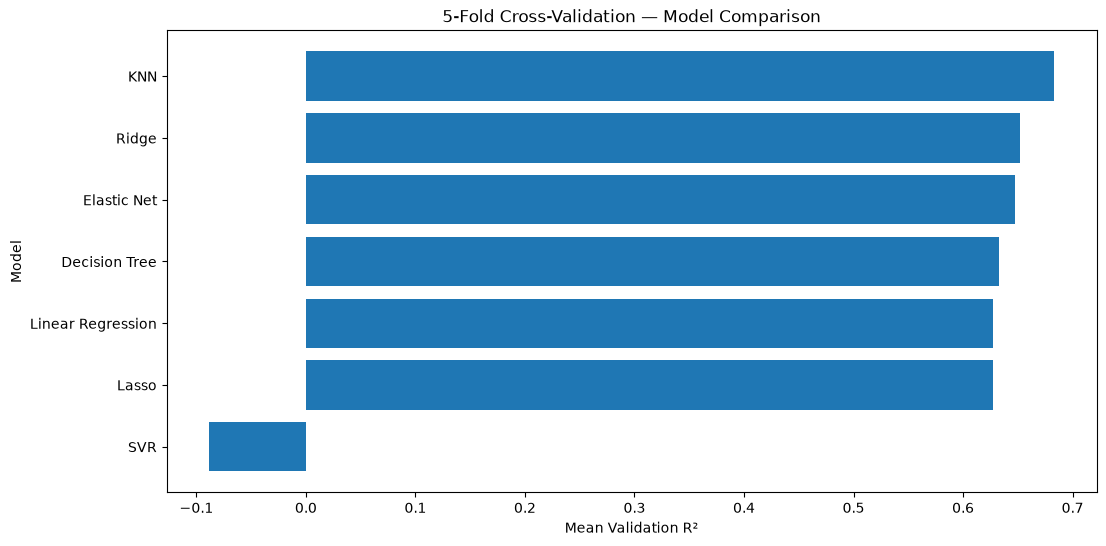

In [156]:
plt.figure(figsize=(12, 6))

plot_data = cv_results_df.sort_values(
    "CV Validation R2"
)

plt.barh(
    plot_data["Model"],
    plot_data["CV Validation R2"]
)

plt.xlabel("Mean Validation R²")
plt.ylabel("Model")
plt.title("5-Fold Cross-Validation — Model Comparison")

plt.show()

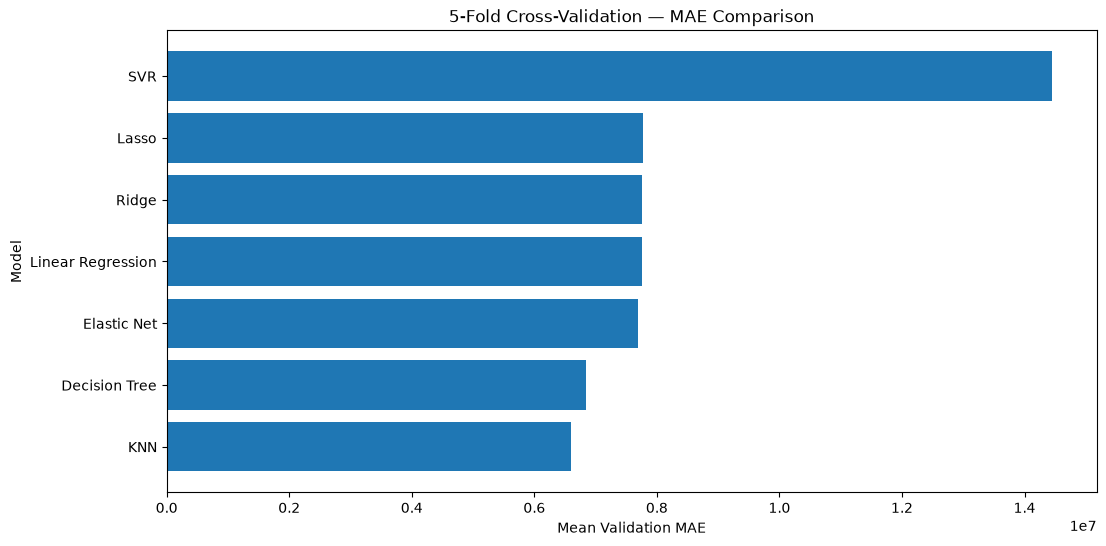

In [157]:
plt.figure(figsize=(12, 6))

plot_data = cv_results_df.sort_values(
    "CV Validation MAE"
)

plt.barh(
    plot_data["Model"],
    plot_data["CV Validation MAE"]
)

plt.xlabel("Mean Validation MAE")
plt.ylabel("Model")
plt.title("5-Fold Cross-Validation — MAE Comparison")

plt.show()

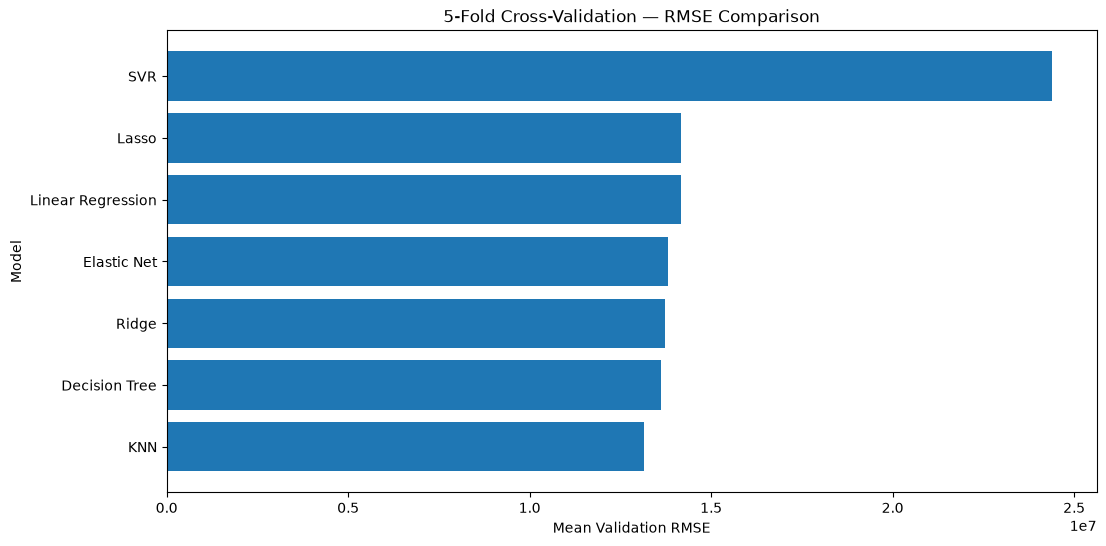

In [158]:
plt.figure(figsize=(12, 6))

plot_data = cv_results_df.sort_values(
    "CV Validation RMSE"
)

plt.barh(
    plot_data["Model"],
    plot_data["CV Validation RMSE"]
)

plt.xlabel("Mean Validation RMSE")
plt.ylabel("Model")
plt.title("5-Fold Cross-Validation — RMSE Comparison")

plt.show()

In [159]:
top_models = cv_results_df.sort_values(
    by="CV Validation R2",
    ascending=False
).head(3)

top_models

,Model,CV Train R2,CV Validation R2,CV Train MAE,CV Validation MAE,CV Train RMSE,CV Validation RMSE
4,KNN,0.820772,0.683378,5.221876e+06,6.603657e+06,1.003597e+07,1.313690e+07
1,Ridge,0.825732,0.652170,5.738278e+06,7.750047e+06,9.900944e+06,1.373667e+07
3,Elastic Net,0.847770,0.647067,5.108106e+06,7.695854e+06,9.252218e+06,1.381661e+07


In [160]:
top_model_names = top_models["Model"].tolist()

cv_stability_df[
    cv_stability_df["Model"].isin(top_model_names)
].sort_values(
    by="Mean CV R2",
    ascending=False
)

,Model,Mean CV R2,Std CV R2
4,KNN,0.683378,0.064067
1,Ridge,0.652170,0.071396
3,Elastic Net,0.647067,0.079720


In [161]:
cv_results_df.to_csv(
    "../data/processed/cross_validation_results.csv",
    index=False
)

cv_stability_df.to_csv(
    "../data/processed/cv_stability_results.csv",
    index=False
)

comparison.to_csv(
    "../data/processed/final_model_comparison.csv",
    index=False
)

print("Cross-validation results saved successfully!")

Cross-validation results saved successfully!


In [162]:
from sklearn.linear_model import HuberRegressor, BayesianRidge
from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

In [163]:
huber_model = HuberRegressor(
    epsilon=1.35,
    max_iter=1000
)

huber_results = evaluate_model(
    huber_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

huber_results

{'Train MAE': 9286932.915902214,
 'Test MAE': 11159109.463880414,
 'Train RMSE': np.float64(17355805.499995865),
 'Test RMSE': np.float64(24404403.25064461),
 'Train R2': 0.46536295742371936,
 'Test R2': 0.3541505510047651}

In [164]:
bayesian_model = BayesianRidge()

bayesian_results = evaluate_model(
    bayesian_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

bayesian_results

{'Train MAE': 15753100.36208908,
 'Test MAE': 17284724.03527402,
 'Train RMSE': np.float64(23736421.84202297),
 'Test RMSE': np.float64(30437757.31013769),
 'Train R2': 6.881384351231645e-12,
 'Test R2': -0.00466253734358224}

In [165]:
extra_trees_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

extra_trees_results = evaluate_model(
    extra_trees_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

extra_trees_results

{'Train MAE': 65911.34751773051,
 'Test MAE': 6245059.863465161,
 'Train RMSE': np.float64(583205.1616027541),
 'Test RMSE': np.float64(13218156.449432526),
 'Train R2': 0.999396312456425,
 'Test R2': 0.8105316451983087}

In [166]:
hist_gradient_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

hist_gradient_results = evaluate_model(
    hist_gradient_model,
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

hist_gradient_results

{'Train MAE': 3935110.7592640277,
 'Test MAE': 7905265.704563706,
 'Train RMSE': np.float64(7600235.376296523),
 'Test RMSE': np.float64(15278941.396272037),
 'Train R2': 0.8974764627854354,
 'Test R2': 0.746847955837276}

In [167]:
advanced_results = pd.DataFrame({
    "Huber Regression": huber_results,
    "Bayesian Ridge": bayesian_results,
    "Extra Trees": extra_trees_results,
    "Hist Gradient Boosting": hist_gradient_results
}).T

advanced_results

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Huber Regression,9.286933e+06,1.115911e+07,1.735581e+07,2.440440e+07,4.653630e-01,0.354151
Bayesian Ridge,1.575310e+07,1.728472e+07,2.373642e+07,3.043776e+07,6.881384e-12,-0.004663
Extra Trees,6.591135e+04,6.245060e+06,5.832052e+05,1.321816e+07,9.993963e-01,0.810532
Hist Gradient Boosting,3.935111e+06,7.905266e+06,7.600235e+06,1.527894e+07,8.974765e-01,0.746848


In [168]:
advanced_results.sort_values(
    by="Test R2",
    ascending=False
)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Extra Trees,6.591135e+04,6.245060e+06,5.832052e+05,1.321816e+07,9.993963e-01,0.810532
Hist Gradient Boosting,3.935111e+06,7.905266e+06,7.600235e+06,1.527894e+07,8.974765e-01,0.746848
Huber Regression,9.286933e+06,1.115911e+07,1.735581e+07,2.440440e+07,4.653630e-01,0.354151
Bayesian Ridge,1.575310e+07,1.728472e+07,2.373642e+07,3.043776e+07,6.881384e-12,-0.004663


In [169]:
advanced_results.sort_values(
    by="Test RMSE",
    ascending=True
)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Extra Trees,6.591135e+04,6.245060e+06,5.832052e+05,1.321816e+07,9.993963e-01,0.810532
Hist Gradient Boosting,3.935111e+06,7.905266e+06,7.600235e+06,1.527894e+07,8.974765e-01,0.746848
Huber Regression,9.286933e+06,1.115911e+07,1.735581e+07,2.440440e+07,4.653630e-01,0.354151
Bayesian Ridge,1.575310e+07,1.728472e+07,2.373642e+07,3.043776e+07,6.881384e-12,-0.004663


In [170]:
advanced_results.sort_values(
    by="Test MAE",
    ascending=True
)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Extra Trees,6.591135e+04,6.245060e+06,5.832052e+05,1.321816e+07,9.993963e-01,0.810532
Hist Gradient Boosting,3.935111e+06,7.905266e+06,7.600235e+06,1.527894e+07,8.974765e-01,0.746848
Huber Regression,9.286933e+06,1.115911e+07,1.735581e+07,2.440440e+07,4.653630e-01,0.354151
Bayesian Ridge,1.575310e+07,1.728472e+07,2.373642e+07,3.043776e+07,6.881384e-12,-0.004663


In [171]:
all_results = pd.concat([
    results,
    advanced_results
])

all_results

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Linear Regression,4.676870e+06,9.081731e+06,9.306332e+06,1.838127e+07,8.462813e-01,0.633608
Ridge,5.838725e+06,9.247760e+06,1.014500e+07,1.821093e+07,8.173274e-01,0.640367
Lasso,4.676870e+06,9.115851e+06,9.306332e+06,1.836861e+07,8.462813e-01,0.634113
Elastic Net,5.382139e+06,9.189080e+06,9.663540e+06,1.815832e+07,8.342544e-01,0.642442
KNN,5.035145e+06,7.238203e+06,9.671986e+06,1.553019e+07,8.339645e-01,0.738454
SVR,1.443982e+07,1.616146e+07,2.479145e+07,3.173919e+07,-9.087115e-02,-0.092412
Decision Tree,2.798846e+06,7.263556e+06,4.476108e+06,1.653842e+07,9.644393e-01,0.703392
Huber Regression,9.286933e+06,1.115911e+07,1.735581e+07,2.440440e+07,4.653630e-01,0.354151
Bayesian Ridge,1.575310e+07,1.728472e+07,2.373642e+07,3.043776e+07,6.881384e-12,-0.004663
Extra Trees,6.591135e+04,6.245060e+06,5.832052e+05,1.321816e+07,9.993963e-01,0.810532


In [172]:
overall_ranking = all_results.sort_values(
    by="Test R2",
    ascending=False
)

overall_ranking

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Extra Trees,6.591135e+04,6.245060e+06,5.832052e+05,1.321816e+07,9.993963e-01,0.810532
Hist Gradient Boosting,3.935111e+06,7.905266e+06,7.600235e+06,1.527894e+07,8.974765e-01,0.746848
KNN,5.035145e+06,7.238203e+06,9.671986e+06,1.553019e+07,8.339645e-01,0.738454
Decision Tree,2.798846e+06,7.263556e+06,4.476108e+06,1.653842e+07,9.644393e-01,0.703392
Elastic Net,5.382139e+06,9.189080e+06,9.663540e+06,1.815832e+07,8.342544e-01,0.642442
Ridge,5.838725e+06,9.247760e+06,1.014500e+07,1.821093e+07,8.173274e-01,0.640367
Lasso,4.676870e+06,9.115851e+06,9.306332e+06,1.836861e+07,8.462813e-01,0.634113
Linear Regression,4.676870e+06,9.081731e+06,9.306332e+06,1.838127e+07,8.462813e-01,0.633608
Huber Regression,9.286933e+06,1.115911e+07,1.735581e+07,2.440440e+07,4.653630e-01,0.354151
Bayesian Ridge,1.575310e+07,1.728472e+07,2.373642e+07,3.043776e+07,6.881384e-12,-0.004663


In [173]:
all_results.sort_values(
    by="Test RMSE",
    ascending=True
)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Extra Trees,6.591135e+04,6.245060e+06,5.832052e+05,1.321816e+07,9.993963e-01,0.810532
Hist Gradient Boosting,3.935111e+06,7.905266e+06,7.600235e+06,1.527894e+07,8.974765e-01,0.746848
KNN,5.035145e+06,7.238203e+06,9.671986e+06,1.553019e+07,8.339645e-01,0.738454
Decision Tree,2.798846e+06,7.263556e+06,4.476108e+06,1.653842e+07,9.644393e-01,0.703392
Elastic Net,5.382139e+06,9.189080e+06,9.663540e+06,1.815832e+07,8.342544e-01,0.642442
Ridge,5.838725e+06,9.247760e+06,1.014500e+07,1.821093e+07,8.173274e-01,0.640367
Lasso,4.676870e+06,9.115851e+06,9.306332e+06,1.836861e+07,8.462813e-01,0.634113
Linear Regression,4.676870e+06,9.081731e+06,9.306332e+06,1.838127e+07,8.462813e-01,0.633608
Huber Regression,9.286933e+06,1.115911e+07,1.735581e+07,2.440440e+07,4.653630e-01,0.354151
Bayesian Ridge,1.575310e+07,1.728472e+07,2.373642e+07,3.043776e+07,6.881384e-12,-0.004663


In [174]:
all_results.sort_values(
    by="Test MAE",
    ascending=True
)

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Extra Trees,6.591135e+04,6.245060e+06,5.832052e+05,1.321816e+07,9.993963e-01,0.810532
KNN,5.035145e+06,7.238203e+06,9.671986e+06,1.553019e+07,8.339645e-01,0.738454
Decision Tree,2.798846e+06,7.263556e+06,4.476108e+06,1.653842e+07,9.644393e-01,0.703392
Hist Gradient Boosting,3.935111e+06,7.905266e+06,7.600235e+06,1.527894e+07,8.974765e-01,0.746848
Linear Regression,4.676870e+06,9.081731e+06,9.306332e+06,1.838127e+07,8.462813e-01,0.633608
Lasso,4.676870e+06,9.115851e+06,9.306332e+06,1.836861e+07,8.462813e-01,0.634113
Elastic Net,5.382139e+06,9.189080e+06,9.663540e+06,1.815832e+07,8.342544e-01,0.642442
Ridge,5.838725e+06,9.247760e+06,1.014500e+07,1.821093e+07,8.173274e-01,0.640367
Huber Regression,9.286933e+06,1.115911e+07,1.735581e+07,2.440440e+07,4.653630e-01,0.354151
SVR,1.443982e+07,1.616146e+07,2.479145e+07,3.173919e+07,-9.087115e-02,-0.092412


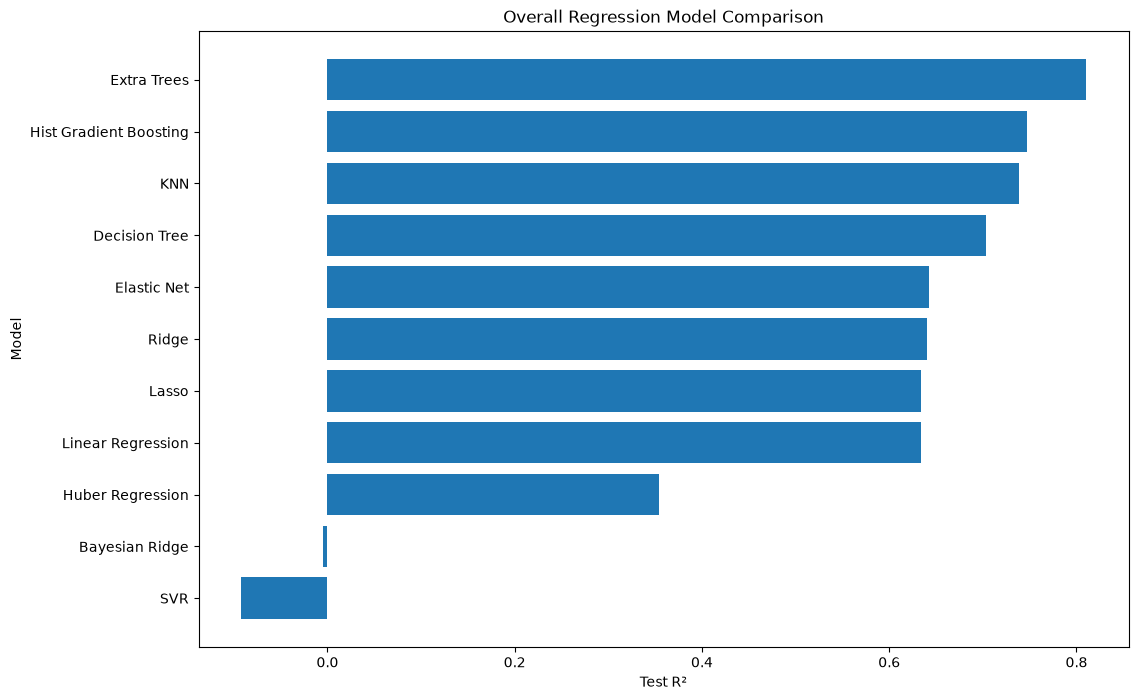

In [175]:
plt.figure(figsize=(12, 8))

plot_data = all_results.sort_values(
    by="Test R2"
)

plt.barh(
    plot_data.index,
    plot_data["Test R2"]
)

plt.xlabel("Test R²")
plt.ylabel("Model")
plt.title("Overall Regression Model Comparison")

plt.show()

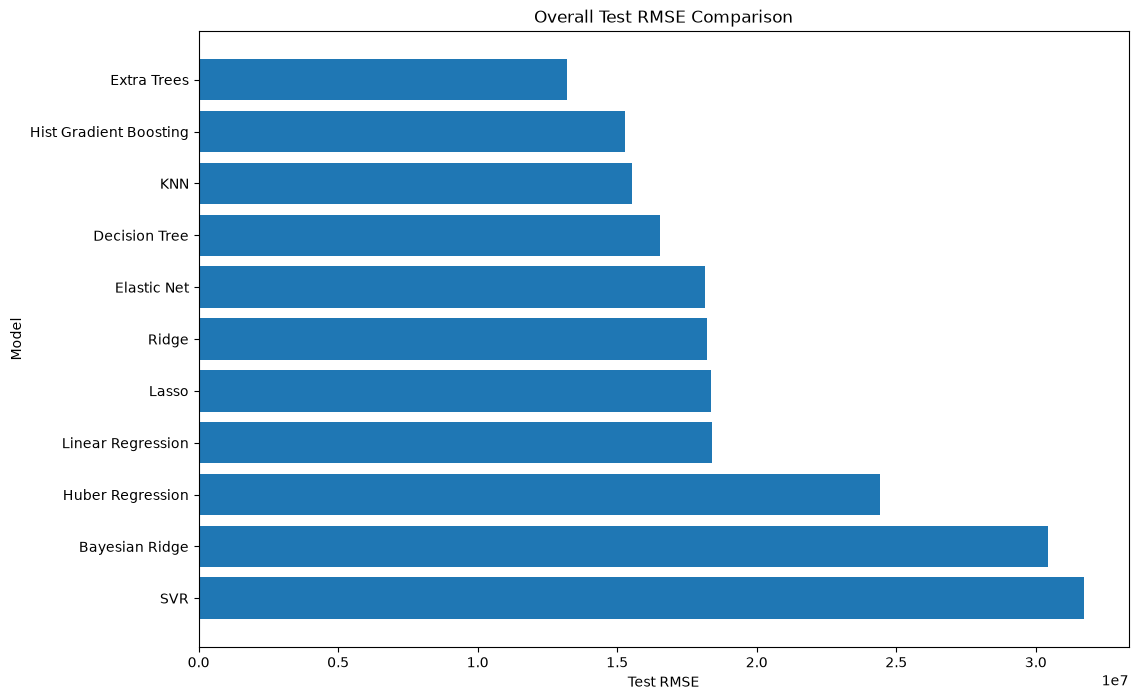

In [176]:
plt.figure(figsize=(12, 8))

plot_data = all_results.sort_values(
    by="Test RMSE",
    ascending=False
)

plt.barh(
    plot_data.index,
    plot_data["Test RMSE"]
)

plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.title("Overall Test RMSE Comparison")

plt.show()

In [177]:
advanced_models = {
    "Huber Regression": HuberRegressor(
        epsilon=1.35,
        max_iter=1000
    ),
    
    "Bayesian Ridge": BayesianRidge(),
    
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}

In [178]:
advanced_cv_results = []

for name, model in advanced_models.items():
    
    scores = cross_validate(
        model,
        X_train_processed,
        y_train,
        cv=kfold,
        scoring=scoring,
        return_train_score=True
    )
    
    advanced_cv_results.append({
        "Model": name,
        
        "CV Train R2": scores["train_r2"].mean(),
        "CV Validation R2": scores["test_r2"].mean(),
        
        "CV Train MAE": -scores["train_mae"].mean(),
        "CV Validation MAE": -scores["test_mae"].mean(),
        
        "CV Train RMSE": -scores["train_rmse"].mean(),
        "CV Validation RMSE": -scores["test_rmse"].mean()
    })

In [179]:
advanced_cv_df = pd.DataFrame(
    advanced_cv_results
)

advanced_cv_df

,Model,CV Train R2,CV Validation R2,CV Train MAE,CV Validation MAE,CV Train RMSE,CV Validation RMSE
0,Huber Regression,4.334588e-01,0.439636,9.576425e+06,9.638489e+06,1.785095e+07,1.759513e+07
1,Bayesian Ridge,5.579359e-12,-0.006505,1.574950e+07,1.577763e+07,2.370661e+07,2.344972e+07
2,Extra Trees,9.994578e-01,0.748167,5.771773e+04,5.872827e+06,5.449737e+05,1.178412e+07
3,Hist Gradient Boosting,8.921244e-01,0.715695,3.938203e+06,6.833709e+06,7.790368e+06,1.245308e+07


In [180]:
all_cv_results = pd.concat([
    cv_results_df,
    advanced_cv_df
], ignore_index=True)

all_cv_results

,Model,CV Train R2,CV Validation R2,CV Train MAE,CV Validation MAE,CV Train RMSE,CV Validation RMSE
0,Linear Regression,8.577124e-01,0.627349,4.443424e+06,7.749589e+06,8.943644e+06,1.417300e+07
1,Ridge,8.257322e-01,0.652170,5.738278e+06,7.750047e+06,9.900944e+06,1.373667e+07
2,Lasso,8.577124e-01,0.627230,4.443424e+06,7.778767e+06,8.943644e+06,1.417363e+07
3,Elastic Net,8.477699e-01,0.647067,5.108106e+06,7.695854e+06,9.252218e+06,1.381661e+07
4,KNN,8.207723e-01,0.683378,5.221876e+06,6.603657e+06,1.003597e+07,1.313690e+07
5,SVR,-8.720640e-02,-0.088515,1.443985e+07,1.445482e+07,2.471746e+07,2.440143e+07
6,Decision Tree,9.665423e-01,0.632431,2.687667e+06,6.839235e+06,4.326155e+06,1.363142e+07
7,Huber Regression,4.334588e-01,0.439636,9.576425e+06,9.638489e+06,1.785095e+07,1.759513e+07
8,Bayesian Ridge,5.579359e-12,-0.006505,1.574950e+07,1.577763e+07,2.370661e+07,2.344972e+07
9,Extra Trees,9.994578e-01,0.748167,5.771773e+04,5.872827e+06,5.449737e+05,1.178412e+07


In [181]:
all_cv_results.sort_values(
    by="CV Validation R2",
    ascending=False
)

,Model,CV Train R2,CV Validation R2,CV Train MAE,CV Validation MAE,CV Train RMSE,CV Validation RMSE
9,Extra Trees,9.994578e-01,0.748167,5.771773e+04,5.872827e+06,5.449737e+05,1.178412e+07
10,Hist Gradient Boosting,8.921244e-01,0.715695,3.938203e+06,6.833709e+06,7.790368e+06,1.245308e+07
4,KNN,8.207723e-01,0.683378,5.221876e+06,6.603657e+06,1.003597e+07,1.313690e+07
1,Ridge,8.257322e-01,0.652170,5.738278e+06,7.750047e+06,9.900944e+06,1.373667e+07
3,Elastic Net,8.477699e-01,0.647067,5.108106e+06,7.695854e+06,9.252218e+06,1.381661e+07
6,Decision Tree,9.665423e-01,0.632431,2.687667e+06,6.839235e+06,4.326155e+06,1.363142e+07
0,Linear Regression,8.577124e-01,0.627349,4.443424e+06,7.749589e+06,8.943644e+06,1.417300e+07
2,Lasso,8.577124e-01,0.627230,4.443424e+06,7.778767e+06,8.943644e+06,1.417363e+07
7,Huber Regression,4.334588e-01,0.439636,9.576425e+06,9.638489e+06,1.785095e+07,1.759513e+07
8,Bayesian Ridge,5.579359e-12,-0.006505,1.574950e+07,1.577763e+07,2.370661e+07,2.344972e+07


In [182]:
advanced_stability = []

for name, model in advanced_models.items():
    
    scores = cross_validate(
        model,
        X_train_processed,
        y_train,
        cv=kfold,
        scoring="r2"
    )
    
    advanced_stability.append({
        "Model": name,
        "Mean CV R2": scores["test_score"].mean(),
        "Std CV R2": scores["test_score"].std()
    })

advanced_stability_df = pd.DataFrame(
    advanced_stability
)

advanced_stability_df

,Model,Mean CV R2,Std CV R2
0,Huber Regression,0.439636,0.059638
1,Bayesian Ridge,-0.006505,0.006783
2,Extra Trees,0.748167,0.042215
3,Hist Gradient Boosting,0.715695,0.059249


In [183]:
advanced_stability_df.sort_values(
    by="Mean CV R2",
    ascending=False
)

,Model,Mean CV R2,Std CV R2
2,Extra Trees,0.748167,0.042215
3,Hist Gradient Boosting,0.715695,0.059249
0,Huber Regression,0.439636,0.059638
1,Bayesian Ridge,-0.006505,0.006783


In [184]:
all_results.to_csv(
    "../data/processed/all_regression_results.csv"
)

all_cv_results.to_csv(
    "../data/processed/all_cross_validation_results.csv",
    index=False
)

advanced_stability_df.to_csv(
    "../data/processed/advanced_model_stability.csv",
    index=False
)

print("All results saved successfully!")

All results saved successfully!


In [186]:
from sklearn.model_selection import RandomizedSearchCV

# Top 3 models
tuning_models = {
    "Extra Trees": (
        ExtraTreesRegressor(random_state=42, n_jobs=-1),
        {
            "n_estimators": [200, 300, 500],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", 1.0]
        }
    ),

    "Hist Gradient Boosting": (
        HistGradientBoostingRegressor(random_state=42),
        {
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "max_iter": [100, 200, 300, 500],
            "max_leaf_nodes": [15, 31, 63],
            "l2_regularization": [0, 0.1, 1, 10]
        }
    ),

    "KNN": (
        KNeighborsRegressor(),
        {
            "n_neighbors": list(range(3, 31, 2)),
            "weights": ["uniform", "distance"],
            "p": [1, 2]
        }
    )
}

tuned_models = {}
tuning_results = []

for name, (model, params) in tuning_models.items():

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=15,
        scoring="r2",
        cv=kfold,
        random_state=42,
        n_jobs=-1,
        refit=True
    )

    search.fit(X_train_processed, y_train)

    tuned_models[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best CV R2": search.best_score_,
        "Best Parameters": search.best_params_
    })

    print(f"\n{name}")
    print("Best CV R²:", search.best_score_)
    print("Best Parameters:", search.best_params_)


# Evaluate tuned models on untouched test set
tuned_results = []

for name, model in tuned_models.items():

    predictions = model.predict(X_test_processed)

    tuned_results.append({
        "Model": name,
        "Test MAE": mean_absolute_error(y_test, predictions),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "Test R2": r2_score(y_test, predictions)
    })

tuned_results_df = pd.DataFrame(tuned_results)

print("\n===== TUNED MODEL RESULTS =====")
display(
    tuned_results_df.sort_values(
        "Test R2",
        ascending=False
    )
)

# Save results
pd.DataFrame(tuning_results).to_csv(
    "../data/processed/hyperparameter_tuning_results.csv",
    index=False
)

tuned_results_df.to_csv(
    "../data/processed/tuned_model_results.csv",
    index=False
)


Extra Trees
Best CV R²: 0.7487283760758028
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 20}

Hist Gradient Boosting
Best CV R²: 0.7352085970279144
Best Parameters: {'max_leaf_nodes': 15, 'max_iter': 500, 'learning_rate': 0.01, 'l2_regularization': 10}

KNN
Best CV R²: 0.717156452974107
Best Parameters: {'weights': 'distance', 'p': 2, 'n_neighbors': 11}

===== TUNED MODEL RESULTS =====


,Model,Test MAE,Test RMSE,Test R2
0,Extra Trees,6.431375e+06,1.357334e+07,0.800213
2,KNN,7.108327e+06,1.498017e+07,0.756652
1,Hist Gradient Boosting,7.880955e+06,1.643061e+07,0.707246


Best tuned model: Extra Trees

===== FINAL TEST METRICS =====
MAE : 6431375.382644426
RMSE: 13573335.794441052
R2  : 0.8002126000129636


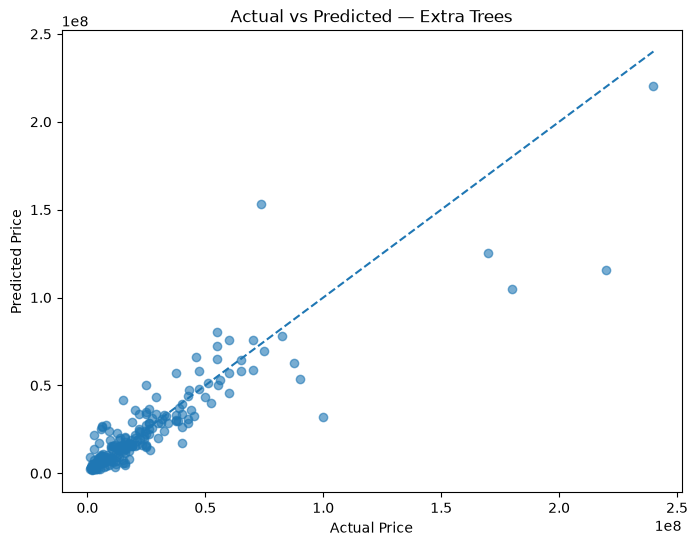

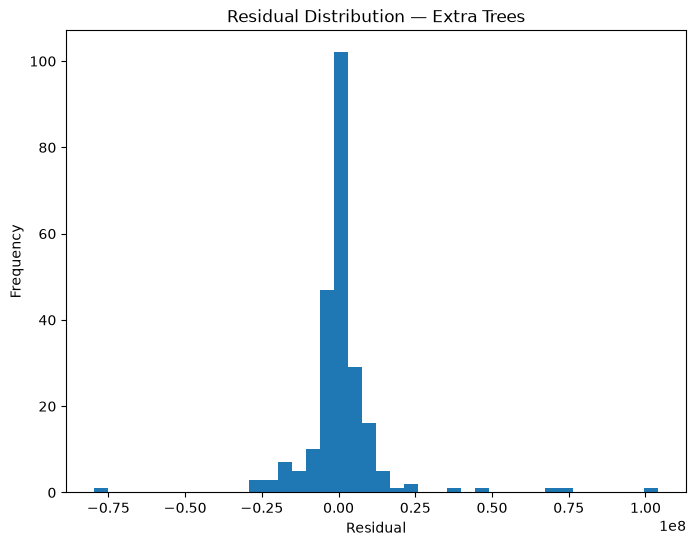

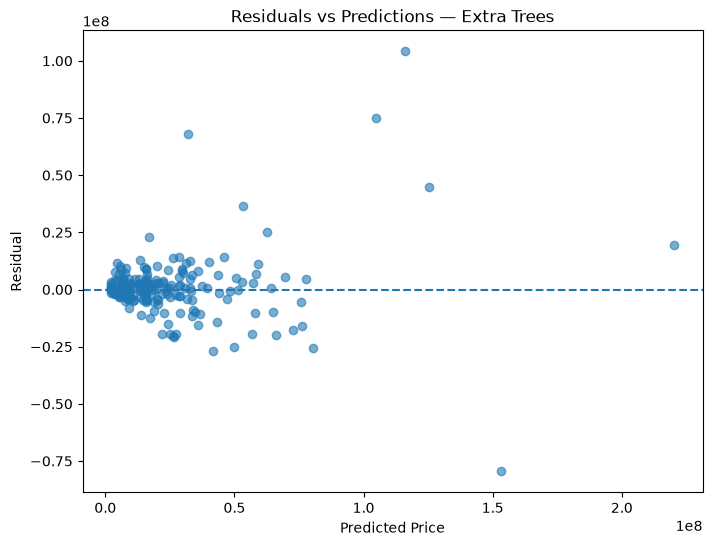


===== 10 LARGEST PREDICTION ERRORS =====


,Actual_Price,Predicted_Price,Residual,Absolute_Error
231,220000000,1.159298e+08,1.040702e+08,1.040702e+08
977,73700000,1.532752e+08,-7.957521e+07,7.957521e+07
1119,180000000,1.048160e+08,7.518401e+07,7.518401e+07
861,100000000,3.189135e+07,6.810865e+07,6.810865e+07
244,170000000,1.253665e+08,4.463348e+07,4.463348e+07
240,90000000,5.348745e+07,3.651255e+07,3.651255e+07
410,15000000,4.187407e+07,-2.687407e+07,2.687407e+07
1171,55000000,8.042898e+07,-2.542898e+07,2.542898e+07
332,25000000,4.999981e+07,-2.499981e+07,2.499981e+07
523,87500000,6.256050e+07,2.493950e+07,2.493950e+07



===== ERROR STATISTICS =====
count    2.360000e+02
mean     6.431375e+06
std      1.197835e+07
min      1.253483e+04
25%      1.035797e+06
50%      2.758377e+06
75%      7.046340e+06
max      1.040702e+08
Name: Absolute_Error, dtype: float64

Error analysis saved successfully.


In [187]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Select best tuned model based on Test R2
best_model_name = tuned_results_df.sort_values(
    "Test R2",
    ascending=False
).iloc[0]["Model"]

best_model = tuned_models[best_model_name]

print("Best tuned model:", best_model_name)


# 2. Predictions
y_pred = best_model.predict(X_test_processed)

# 3. Residuals
residuals = y_test - y_pred

print("\n===== FINAL TEST METRICS =====")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))


# 4. Actual vs Predicted
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted — {best_model_name}")

plt.show()


# 5. Residual Distribution
plt.figure(figsize=(8, 6))

plt.hist(residuals, bins=40)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title(f"Residual Distribution — {best_model_name}")

plt.show()


# 6. Residuals vs Predictions
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title(f"Residuals vs Predictions — {best_model_name}")

plt.show()


# 7. Largest Prediction Errors
error_analysis = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": y_pred,
    "Residual": residuals,
    "Absolute_Error": np.abs(residuals)
})

largest_errors = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

print("\n===== 10 LARGEST PREDICTION ERRORS =====")
display(largest_errors)


# 8. Error statistics
print("\n===== ERROR STATISTICS =====")
print(error_analysis["Absolute_Error"].describe())


# 9. Save error analysis
error_analysis.to_csv(
    "../data/processed/error_analysis.csv",
    index=False
)

print("\nError analysis saved successfully.")

In [188]:
from sklearn.base import clone
import joblib
import os
import pandas as pd

# 1. Select best tuned model
best_model_name = tuned_results_df.sort_values(
    "Test R2",
    ascending=False
).iloc[0]["Model"]

best_model = tuned_models[best_model_name]

print("Selected Final Model:", best_model_name)


# 2. Final test performance
y_pred = best_model.predict(X_test_processed)

final_test_metrics = {
    "Model": best_model_name,
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "R2": r2_score(y_test, y_pred)
}

print("\n===== FINAL TEST PERFORMANCE =====")
print(f"MAE  : {final_test_metrics['MAE']:,.2f}")
print(f"RMSE : {final_test_metrics['RMSE']:,.2f}")
print(f"R²   : {final_test_metrics['R2']:.4f}")


# 3. Prepare complete dataset for final deployment model
X_full = df[features].copy()
y_full = df[target].copy()

# Same categorical conversion used during preprocessing
for column in categorical_features:
    X_full[column] = X_full[column].astype(str)


# 4. Fit a fresh preprocessor on complete dataset
final_preprocessor = clone(preprocessor)

X_full_processed = final_preprocessor.fit_transform(X_full)


# 5. Clone best model with its tuned parameters
final_model = clone(best_model)

# Train on complete dataset
final_model.fit(X_full_processed, y_full)


# 6. Create models directory
os.makedirs("../models", exist_ok=True)


# 7. Save final model and preprocessing
joblib.dump(
    final_model,
    "../models/final_house_price_model.pkl"
)

joblib.dump(
    final_preprocessor,
    "../models/final_preprocessor.pkl"
)


# 8. Save model information
model_info = pd.DataFrame([{
    "Final Model": best_model_name,
    "Test MAE": final_test_metrics["MAE"],
    "Test RMSE": final_test_metrics["RMSE"],
    "Test R2": final_test_metrics["R2"]
}])

model_info.to_csv(
    "../data/processed/final_model_info.csv",
    index=False
)


print("\n================================")
print("FINAL MODEL READY")
print("================================")
print("Model:", best_model_name)
print("Model saved: final_house_price_model.pkl")
print("Preprocessor saved: final_preprocessor.pkl")
print("Training data used: Complete dataset")

Selected Final Model: Extra Trees

===== FINAL TEST PERFORMANCE =====
MAE  : 6,431,375.38
RMSE : 13,573,335.79
R²   : 0.8002

FINAL MODEL READY
Model: Extra Trees
Model saved: final_house_price_model.pkl
Preprocessor saved: final_preprocessor.pkl
Training data used: Complete dataset


In [190]:
import joblib
import pandas as pd
import numpy as np

# 1. Load final model + preprocessor
final_model = joblib.load(
    "../models/final_house_price_model.pkl"
)

final_preprocessor = joblib.load(
    "../models/final_preprocessor.pkl"
)


# 2. Create prediction function
def predict_house_price(
    area,
    bhk,
    bathroom,
    furnishing,
    locality,
    parking,
    status,
    transaction,
    property_type
):
    
    new_house = pd.DataFrame([{
        "Area": area,
        "BHK": bhk,
        "Bathroom": bathroom,
        "Furnishing": furnishing,
        "Locality": locality,
        "Parking": parking,
        "Status": status,
        "Transaction": transaction,
        "Type": property_type
    }])

    # Feature engineering
    new_house["Total_Rooms"] = (
        new_house["BHK"] +
        new_house["Bathroom"]
    )

    new_house["Area_per_BHK"] = (
        new_house["Area"] /
        new_house["BHK"]
    )

    # Ensure categorical columns are strings
    for column in categorical_features:
        new_house[column] = new_house[column].astype(str)

    # Keep exact feature order
    new_house = new_house[features]

    # Preprocess
    processed_house = final_preprocessor.transform(
        new_house
    )

    # Predict
    prediction = final_model.predict(
        processed_house
    )[0]

    return prediction


# 3. Test with a new house
predicted_price = predict_house_price(
    area=1500,
    bhk=3,
    bathroom=2,
    furnishing="Semi-Furnished",
    locality="Dwarka",
    parking="1",
    status="Ready_to_move",
    transaction="Resale",
    property_type="Flat"
)


print("HOUSE PRICE PREDICTION")
print(f"Predicted Price: ₹{predicted_price:,.2f}")

HOUSE PRICE PREDICTION
Predicted Price: ₹15,810,252.89


In [191]:
# House 1
print(
    "House 1:",
    f"₹{predict_house_price(
        1000, 2, 2,
        "Semi-Furnished",
        "Dwarka", "1",
        "Ready_to_move",
        "Resale",
        "Flat"
    ):,.2f}"
)


# House 2
print(
    "House 2:",
    f"₹{predict_house_price(
        1800, 3, 3,
        "Furnished",
        "Gurgaon", "2",
        "Ready_to_move",
        "New_Property",
        "Flat"
    ):,.2f}"
)


# House 3
print(
    "House 3:",
    f"₹{predict_house_price(
        2500, 4, 4,
        "Furnished",
        "Gurgaon", "3",
        "Ready_to_move",
        "Resale",
        "House"
    ):,.2f}"
)

House 1: ₹8,655,885.17
House 2: ₹29,295,243.60
House 3: ₹37,401,608.05
